# DSAA2011 ML Project — Predicting Student Outcomes

**Course:** DSAA2011 (Spring 2026) · **Dataset:** Student academic performance (~4424 records, 36 features) · **Target:** `Dropout` / `Enrolled` / `Graduate`

This notebook merges all six phases of the project — data preprocessing, t-SNE visualization, clustering, classification, evaluation, and open-ended exploration (hyperparameter tuning + feature engineering) — into a single submission artefact, paired with the formal LaTeX report under `report/`.


# 01 Data Preprocessing

This notebook loads the Student Dropout dataset, inspects its structure, handles missing and non-numeric values, and standardizes features to prepare for downstream tasks (t-SNE, clustering, prediction).

In [1]:
import warnings
# Notebook-wide filter: macOS Accelerate BLAS emits spurious 'divide by zero /
# overflow in matmul' RuntimeWarnings inside sklearn fits that converge
# correctly. Also silence FutureWarning and ConvergenceWarning so downstream
# sections inherit a clean output stream.
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import pandas as pd
import numpy as np

df = pd.read_csv('data/data.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()


Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1. Basic Inspection

We first examine data types, missing values, and duplicates to understand the dataset's overall quality.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [3]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
# Check missing values
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0] if missing.any() else 'None — dataset has no missing values.')

Columns with missing values:
None — dataset has no missing values.


In [5]:
# Check duplicate rows
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'After removal: {df.shape}')

Duplicate rows: 0


In [6]:
# Target distribution
print('Target distribution:')
print(df['Target'].value_counts())
print(f'\nPercentages:')
print(df['Target'].value_counts(normalize=True).round(3))

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentages:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


### Observations

- **No missing values** across all 37 columns — no imputation needed.
- **No duplicate rows.**
- **Class imbalance**: Graduate (~50%) is the majority class, followed by Dropout (~32%) and Enrolled (~18%). This imbalance should be considered during model training and evaluation.
- All features except `Target` are already numeric (int64 or float64), but many integer columns are actually **categorical codes** (e.g., `Course`, `Nationality`).
- The raw file ships with a known misspelling, `Nacionality`, which we correct in the next step.

## 2. Column Name Cleanup

Some column names contain trailing tabs and quotes from the CSV — we strip these for consistency. We also rename `Nacionality` to `Nationality`: the official dataset ships with this misspelling, and correcting it here ensures every downstream notebook uses the canonical name.

In [7]:
df.columns = df.columns.str.strip().str.strip('"').str.strip()
df.rename(columns={'Nacionality': 'Nationality'}, inplace=True)
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nationality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

## 3. Identify Feature Types

Although all features are numeric, many are integer-coded categorical variables. We classify columns into three groups:
- **Binary**: already 0/1 (e.g., Gender, Displaced)
- **Nominal categorical**: integer codes with no ordinal meaning (e.g., Course, Nationality)
- **Continuous numeric**: truly numeric features (e.g., grades, age)

In [8]:
# Columns with few unique values
print('Columns with <= 20 unique values (likely categorical):\n')
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 20:
        print(f'  {col}: {n_unique} unique')

Columns with <= 20 unique values (likely categorical):

  Marital status: 6 unique
  Application mode: 18 unique
  Application order: 8 unique
  Course: 17 unique
  Daytime/evening attendance: 2 unique
  Previous qualification: 17 unique
  Displaced: 2 unique
  Educational special needs: 2 unique
  Debtor: 2 unique
  Tuition fees up to date: 2 unique
  Gender: 2 unique
  Scholarship holder: 2 unique
  International: 2 unique
  Curricular units 1st sem (without evaluations): 11 unique
  Curricular units 2nd sem (credited): 19 unique
  Curricular units 2nd sem (approved): 20 unique
  Curricular units 2nd sem (without evaluations): 10 unique
  Unemployment rate: 10 unique
  Inflation rate: 9 unique
  GDP: 10 unique
  Target: 3 unique


In [9]:
# Binary columns (already 0/1)
binary_cols = [col for col in df.columns if set(df[col].unique()) <= {0, 1}]
print(f'Binary columns ({len(binary_cols)}):', binary_cols)

# Nominal categorical columns (integer-coded, no ordinal meaning)
nominal_cols = [
    'Marital status', 'Application mode', 'Course',
    'Nationality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Previous qualification'
]
print(f'\nNominal categorical columns ({len(nominal_cols)}):', nominal_cols)

# Continuous numeric columns (everything else except Target)
numeric_cols = [col for col in df.columns
                if col not in binary_cols + nominal_cols + ['Target']]
print(f'\nContinuous numeric columns ({len(numeric_cols)}):', numeric_cols)

Binary columns (8): ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Nominal categorical columns (9): ['Marital status', 'Application mode', 'Course', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Previous qualification']

Continuous numeric columns (19): ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (wi

## 4. Handle Non-Numeric Values

The `Target` column is the only non-numeric (object) column. We encode it using Label Encoding for model training.

For the **nominal categorical columns** (integer-coded but with no ordinal relationship), we apply **one-hot encoding** so that models do not incorrectly assume ordering between categories. To keep dimensionality manageable, we use `drop_first=True` to avoid multicollinearity.

In [10]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
df['Target_encoded'] = le.fit_transform(df['Target'])
print('Target encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

Target encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [11]:
# One-hot encode nominal categorical columns
print(f'Shape before one-hot encoding: {df.shape}')

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f'Shape after one-hot encoding:  {df_encoded.shape}')
print(f'\nNew columns added: {df_encoded.shape[1] - df.shape[1]}')

Shape before one-hot encoding: (4424, 38)
Shape after one-hot encoding:  (4424, 240)

New columns added: 202


## 5. Outlier Detection

We use the IQR method to identify outliers in continuous features. We report them here for awareness but **do not remove** them at this stage — many "outliers" (e.g., 0 grades for dropouts) are valid data points. Removal decisions should be made during modeling based on impact.

In [12]:
print('IQR-based outlier counts for continuous features:\n')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)')

IQR-based outlier counts for continuous features:

  Application order: 541 outliers (12.2%)
  Previous qualification (grade): 179 outliers (4.0%)
  Admission grade: 86 outliers (1.9%)
  Age at enrollment: 441 outliers (10.0%)
  Curricular units 1st sem (credited): 577 outliers (13.0%)
  Curricular units 1st sem (enrolled): 424 outliers (9.6%)
  Curricular units 1st sem (evaluations): 158 outliers (3.6%)
  Curricular units 1st sem (approved): 180 outliers (4.1%)
  Curricular units 1st sem (grade): 726 outliers (16.4%)
  Curricular units 1st sem (without evaluations): 294 outliers (6.6%)
  Curricular units 2nd sem (credited): 530 outliers (12.0%)
  Curricular units 2nd sem (enrolled): 369 outliers (8.3%)
  Curricular units 2nd sem (evaluations): 109 outliers (2.5%)
  Curricular units 2nd sem (approved): 44 outliers (1.0%)
  Curricular units 2nd sem (grade): 877 outliers (19.8%)
  Curricular units 2nd sem (without evaluations): 282 outliers (6.4%)


### Observations

- **Curricular unit grades** (1st & 2nd sem) have the most outliers (16-20%) — this is expected because dropout students often have 0 grades, which fall far below the IQR.
- **Age at enrollment** has ~10% outliers, reflecting mature/non-traditional students.
- **Credited units** (1st & 2nd sem) have ~12-13% outliers, corresponding to students with transfer credits.

## 6. Feature Standardization

We apply **StandardScaler** (zero mean, unit variance) to all continuous numeric features. This is important for:
- **t-SNE** (Phase 2): sensitive to feature scales
- **Clustering** (Phase 3): distance-based algorithms like K-means require scaled features
- **Models** (Phase 4): logistic regression and other algorithms benefit from standardization

Binary columns are left as-is (already 0/1). One-hot encoded columns are also left as-is (already 0/1).

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print('After standardization (continuous features):')
df_encoded[numeric_cols].describe().loc[['mean', 'std']].round(4)

After standardization (continuous features):


,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
mean,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001


## 7. Save Preprocessed Data

We save two versions:
- `data_cleaned.csv`: column names cleaned, target encoded, but **no** one-hot encoding or scaling (for EDA/visualization)
- `data_preprocessed.csv`: fully preprocessed with one-hot encoding and standardization (for clustering and modeling)

In [14]:
# Cleaned version (no encoding/scaling, useful for EDA)
df.to_csv('data/data_cleaned.csv', index=False)
print(f'Saved data_cleaned.csv: {df.shape}')

# Fully preprocessed version (one-hot encoded + standardized)
df_encoded.to_csv('data/data_preprocessed.csv', index=False)
print(f'Saved data_preprocessed.csv: {df_encoded.shape}')

Saved data_cleaned.csv: (4424, 38)
Saved data_preprocessed.csv: (4424, 240)


## Summary

| Step | Method | Result |
|------|--------|--------|
| Missing values | Checked with `isnull()` | None found |
| Duplicates | Checked with `duplicated()` | None found |
| Column cleanup | Strip whitespace/tabs | Fixed `Daytime/evening attendance` |
| Non-numeric handling | LabelEncoder for Target, one-hot encoding (`pd.get_dummies`) for 9 nominal columns | Expanded from 37 to 240 columns |
| Standardization | StandardScaler on 19 continuous features | Zero mean, unit variance |
| Outliers | IQR detection | Reported but not removed (valid data points) |

**Key patterns observed:**
- The dataset is clean with no missing values or duplicates.
- Class imbalance exists: Graduate ~50%, Dropout ~32%, Enrolled ~18%.
- Most features are integer-coded categories rather than true numeric values.
- High outlier counts in grade columns are driven by dropout students with zero grades, not data errors.

# 02 Data Visualization

This notebook applies **t-SNE** (t-distributed Stochastic Neighbor Embedding) to the preprocessed student dataset to visualize high-dimensional data in 2D and 3D. Points are colored by the Target class (Dropout / Enrolled / Graduate) to reveal clustering patterns.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Load preprocessed data (standardized + one-hot encoded). Re-loading here keeps
# this section self-contained when read in isolation.
df = pd.read_csv('data/data_preprocessed.csv')

# Separate features and target
target = df['Target']
target_encoded = df['Target_encoded']
X = df.drop(columns=['Target', 'Target_encoded'])

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')


Feature matrix shape: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1. t-SNE 2D Visualization

We reduce the high-dimensional feature space to 2 dimensions using t-SNE. Key parameters:
- `perplexity=30`: balances local vs. global structure (default, works well for datasets of this size)
- `random_state=42`: for reproducibility
- `max_iter=1000`: sufficient iterations for convergence

In [16]:
# Run t-SNE for 2D embedding
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne_2d.fit_transform(X)

print(f't-SNE 2D embedding shape: {X_2d.shape}')
print(f'KL divergence: {tsne_2d.kl_divergence_:.4f}')

t-SNE 2D embedding shape: (4424, 2)
KL divergence: 1.5826


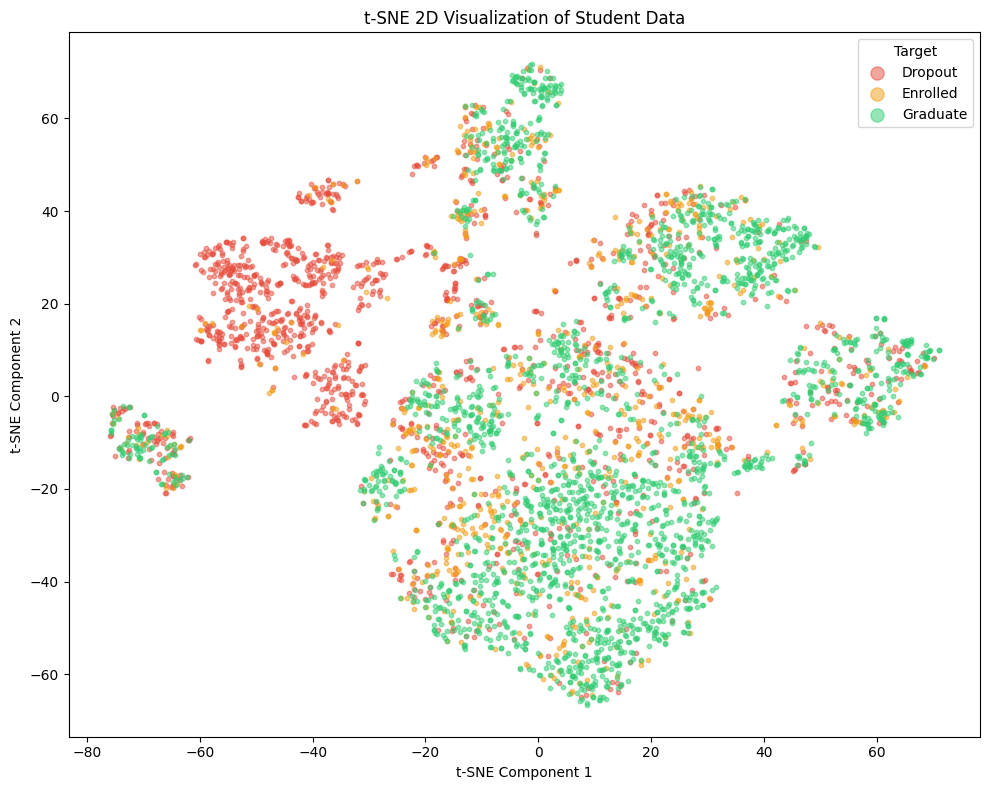

In [17]:
# 2D scatter plot colored by Target class
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Dropout': '#e74c3c', 'Enrolled': '#f39c12', 'Graduate': '#2ecc71'}
for label in ['Dropout', 'Enrolled', 'Graduate']:
    mask = target == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[label], label=label, alpha=0.5, s=10)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE 2D Visualization of Student Data')
ax.legend(title='Target', markerscale=3)
plt.tight_layout()
plt.savefig('outputs/tsne_2d.png', dpi=150)
plt.show()

## 2. t-SNE 3D Visualization

A 3D embedding can sometimes reveal additional structure not visible in 2D.

In [18]:
# Run t-SNE for 3D embedding
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, max_iter=1000)
X_3d = tsne_3d.fit_transform(X)

print(f't-SNE 3D embedding shape: {X_3d.shape}')
print(f'KL divergence: {tsne_3d.kl_divergence_:.4f}')

t-SNE 3D embedding shape: (4424, 3)
KL divergence: 1.3984


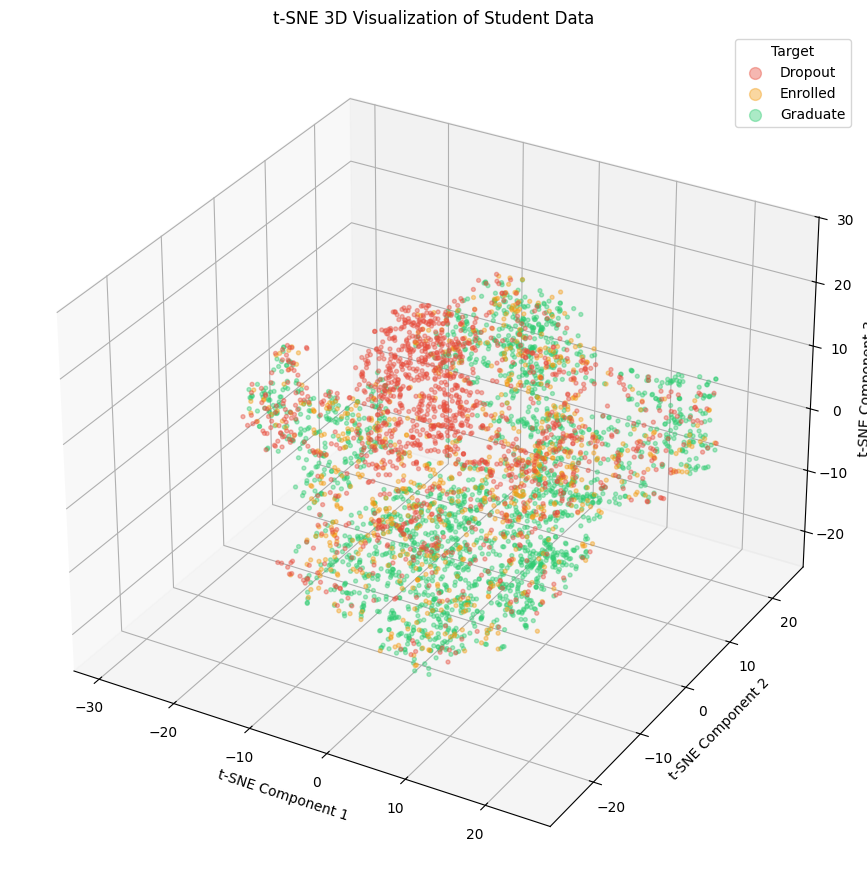

In [19]:
# 3D scatter plot colored by Target class
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for label in ['Dropout', 'Enrolled', 'Graduate']:
    mask = target == label
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               c=colors[label], label=label, alpha=0.4, s=8)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title('t-SNE 3D Visualization of Student Data')
ax.legend(title='Target', markerscale=3)
plt.tight_layout()
plt.savefig('outputs/tsne_3d.png', dpi=150)
plt.show()

## 3. Effect of Perplexity

Perplexity controls how t-SNE balances local vs. global structure. We compare multiple values to check robustness of the observed patterns.

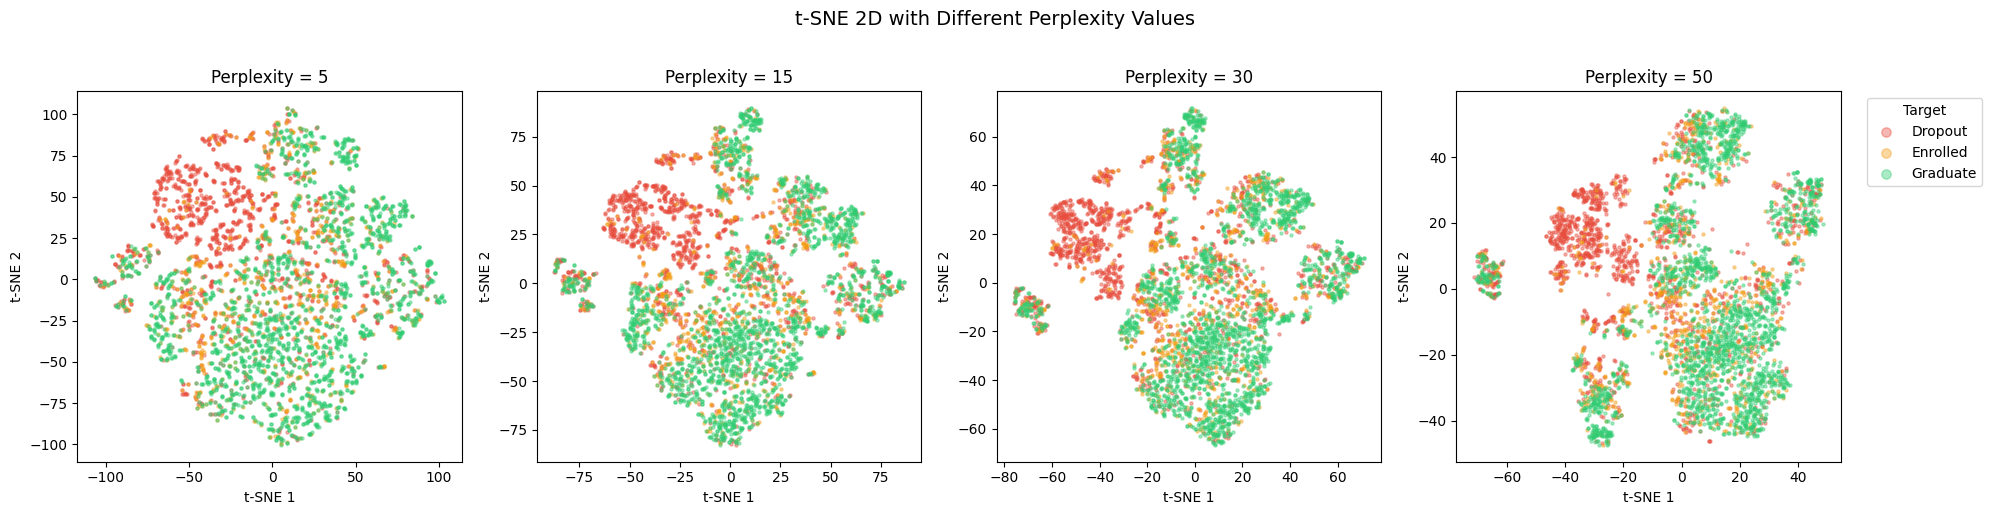

In [20]:
# Compare different perplexity values
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_emb = tsne.fit_transform(X)
    for label in ['Dropout', 'Enrolled', 'Graduate']:
        mask = target == label
        ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                   c=colors[label], label=label, alpha=0.4, s=5)
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[-1].legend(title='Target', markerscale=3, bbox_to_anchor=(1.05, 1))
plt.suptitle('t-SNE 2D with Different Perplexity Values', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('outputs/tsne_perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analysis

### Observations

1. **Cluster separation**: Dropout students (red) tend to cluster on the **left side** of the 2D embedding, while Graduate students (green) dominate the **right and bottom** regions. This suggests meaningful differences in their feature profiles.

2. **Overlap regions**: Enrolled students (orange) are **heavily mixed** with both Dropout and Graduate clusters, particularly in the central region. This makes sense — enrolled students haven't reached a final outcome yet and may share characteristics with either group. Predicting the Enrolled class will likely be the hardest task.

3. **Sub-clusters**: Multiple small, tight clusters are visible (especially in the upper-right for Graduates and upper-left for Dropouts). These likely correspond to different **Course** or **Application mode** categories from the one-hot encoding, grouping students with similar academic programs.

4. **Perplexity sensitivity**: The class separation pattern is **consistent across all perplexity values** (5, 15, 30, 50), confirming that the observed structure is genuine and not an artifact. Lower perplexity (5) produces a more diffuse, spread-out embedding; higher values (30, 50) reveal more distinct, tightly grouped sub-clusters as the algorithm captures broader neighborhood structure.

### Implications for Modeling

- The partial separability between Dropout and Graduate classes suggests that **classification models should achieve reasonable accuracy** for these two classes.
- The Enrolled class overlap indicates it will be the most challenging to predict — consider whether to treat this as a **binary problem** (Dropout vs. Graduate) in addition to the 3-class task.
- The presence of sub-clusters suggests that **Course** and other categorical features play a strong role in defining student groups.

# 03 Clustering Analysis

This notebook conducts clustering analysis on the student dropout dataset, covering algorithm introduction, data loading, feature selection, clustering modeling, visualization, and multi-metric evaluation for K-means, Hierarchical Clustering, and Gaussian Mixture Model (GMM).

## 1. K-means algorithm

K-means is a commonly used distance-based clustering algorithm suitable for numerical features. Its goal is to divide data into K clusters such that the similarity of samples within the same cluster is maximized and the similarity between different clusters is minimized. It is applicable to large-sample datasets with standardized features.

In [7]:
import warnings
# macOS Accelerate BLAS emits spurious 'divide by zero / overflow in matmul'
# warnings during sklearn internals; fits converge correctly. Silence the noise.
warnings.filterwarnings('ignore', category=RuntimeWarning)

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Plotting style configuration
cluster_palette = ['#e41a1c', '#4daf4a', '#377eb8']
plt.rcParams.update({'figure.figsize': (10, 8), 'figure.dpi': 100})
plt.rcParams['savefig.dpi'] = 150
# Subplot margins to match tight_layout
plt.rcParams['figure.subplot.top'] = 0.95
plt.rcParams['figure.subplot.bottom'] = 0.05
plt.rcParams['figure.subplot.left'] = 0.05
plt.rcParams['figure.subplot.right'] = 0.95
# Seaborn style
sns.set_style('whitegrid')
POINT_SIZE = 10
POINT_ALPHA = 0.7
LEGEND_MARKERSCALE = 3
LEGEND_BBOX = dict(bbox_to_anchor=(1.05, 1), loc='upper left')

### 1.1. Read preprocessed data
Use the standardized and one-hot encoded data generated by 01_preprocessing.ipynb.

In [3]:
df = pd.read_csv('data/data_preprocessed.csv')
df.shape, df.columns[:5]

((4424, 240),
 Index(['Application order', 'Daytime/evening attendance',
        'Previous qualification (grade)', 'Admission grade', 'Displaced'],
       dtype='object'))

In [4]:
# Use one-hot encoded dataframe (drop target columns) — expected feature dim ~238
drop_cols = [c for c in ['Target', 'Target_encoded'] if c in df.columns]
X = df.drop(columns=drop_cols)
X.shape

(4424, 238)

### 1.2. Feature selection

Remove the target variable and encoded columns, and perform clustering using only the features.

In [5]:
X_scaled = X.values
# PCA for 2D visualization (computed once and reused)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape
# t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

### 1.3. K-means Clustering Modeling and Clustering Visualization Under Different K Values (PCA Dimensionality Reduction)

d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(


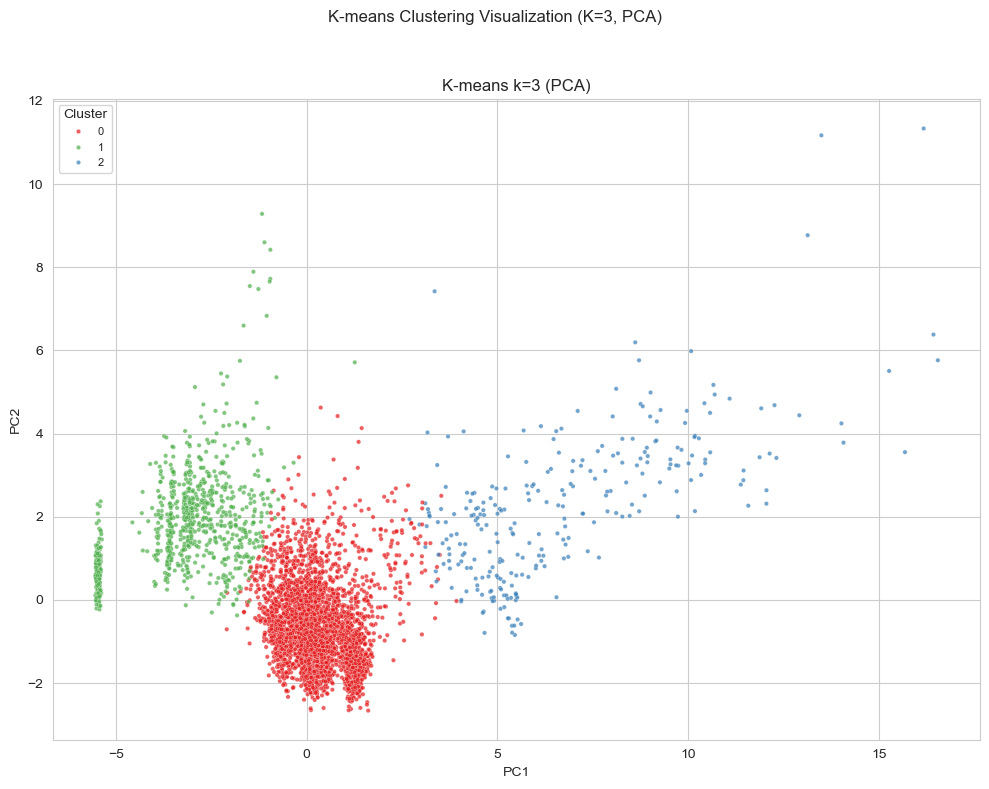

In [8]:
k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'K-means k={k} (PCA)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('K-means Clustering Visualization (K=3, PCA)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(


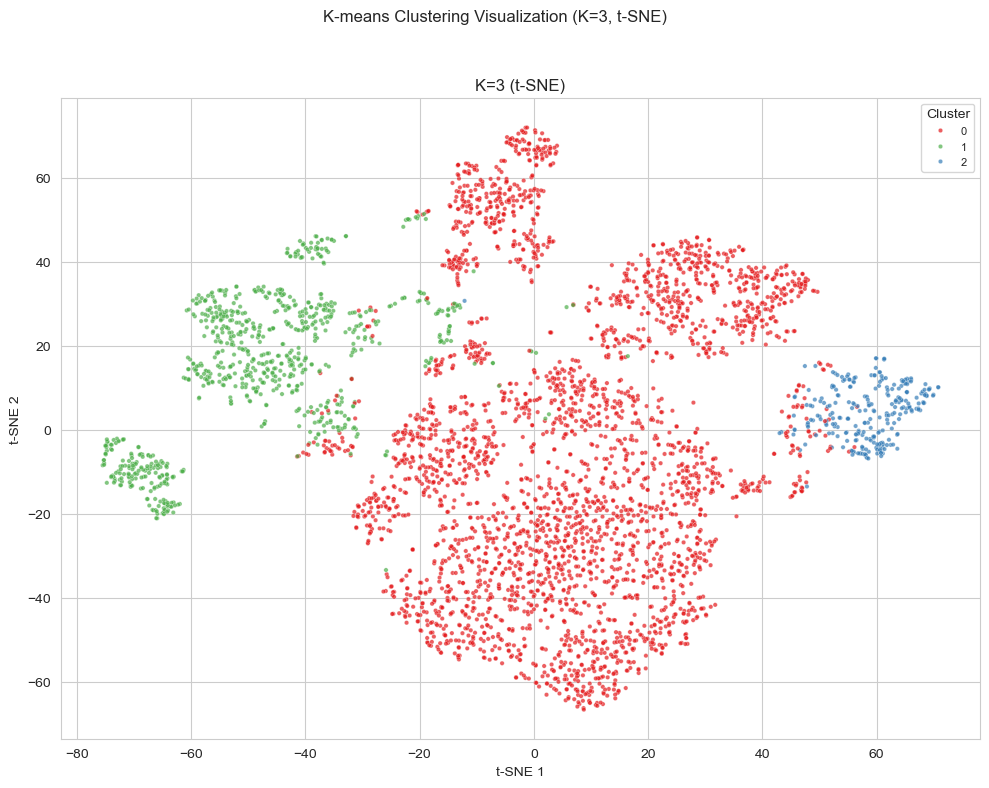

In [9]:
# K-means t-SNE visualization, directly reuse X_tsne
fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'K={k} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('K-means Clustering Visualization (K=3, t-SNE)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 1.4. Clustering effect evaluation
The following compares various clustering evaluation metrics under different K values:
- Elbow Method: (As K increases, the SSE will keep decreasing, but when K is excessively large, the decline rate of SSE will become very small.) The "elbow" refers to the point where the SSE curve bends noticeably, and the K corresponding to the inflection point is regarded as the optimal number of clusters.
- Silhouette Coefficient: Measures intra-cluster compactness and inter-cluster separation, with a range of [-1, 1]; the closer to 1, the better.
- Calinski-Harabasz (CH): Ratio of inter-cluster variance to intra-cluster variance; the higher the value, the better.
- Davies-Bouldin (DB): Ratio of intra-cluster similarity to inter-cluster similarity; the lower the value, the better.
- ARI / Normalized Mutual Information (NMI): Compares clustering results with true labels; the closer to 1, the better.

In [10]:
def purity_score(y_true, y_pred):
    from scipy.stats import mode
    labels = np.unique(y_pred)
    total = 0
    for label in labels:
        mask = (y_pred == label)
        if np.sum(mask) == 0: continue
        if len(np.unique(y_true[mask])) == 0: continue
        
        m = mode(y_true[mask], keepdims=True)
        if hasattr(m, 'count'):
            total += m.count[0]
        else:
            total += m[1][0]
    return total / len(y_true)

K_range = [3]
inertia = []
silhouette = []
ch_score = []
db_score = []
ari_score = []
nmi_score = []
purity = []
true_labels = df['Target_encoded'] if 'Target_encoded' in df.columns else None

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette.append(silhouette_score(X_scaled, labels))
    ch_score.append(calinski_harabasz_score(X_scaled, labels))
    db_score.append(davies_bouldin_score(X_scaled, labels))
    if true_labels is not None:
        ari_score.append(adjusted_rand_score(true_labels, labels))
        nmi_score.append(normalized_mutual_info_score(true_labels, labels))
        purity.append(purity_score(true_labels, labels))
    else:
        ari_score.append(None)
        nmi_score.append(None)
        purity.append(None)

# Summarize K-means evaluation metrics as a table
results_kmeans = pd.DataFrame({
    'K': list(K_range),
    'Silhouette': silhouette,
    'CH': ch_score,
    'DB': db_score,
    'ARI': ari_score,
    'NMI': nmi_score,
    'Purity': purity,
})
display(results_kmeans.style.format({'Inertia': '{:.2f}', 'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('K-means Evaluation Metrics'))

d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(


,K,Silhouette,CH,DB,ARI,NMI,Purity
0,3,0.245,804.66,1.67,0.149,0.157,0.639


## 2. Hierarchical Clustering
Hierarchical Clustering constructs a clustering tree from data objects. Common hierarchical clustering methods include agglomerative (bottom-up merging) and divisive (top-down splitting), with agglomerative clustering being more widely used. Hierarchical clustering is suitable for data analysis scenarios with a small sample size where a hierarchical clustering structure is desired.

### 2.1 Hierarchical clustering dendrogram
Plot a dendrogram for hierarchical clustering to observe the hierarchical structure and clustering process of the samples.

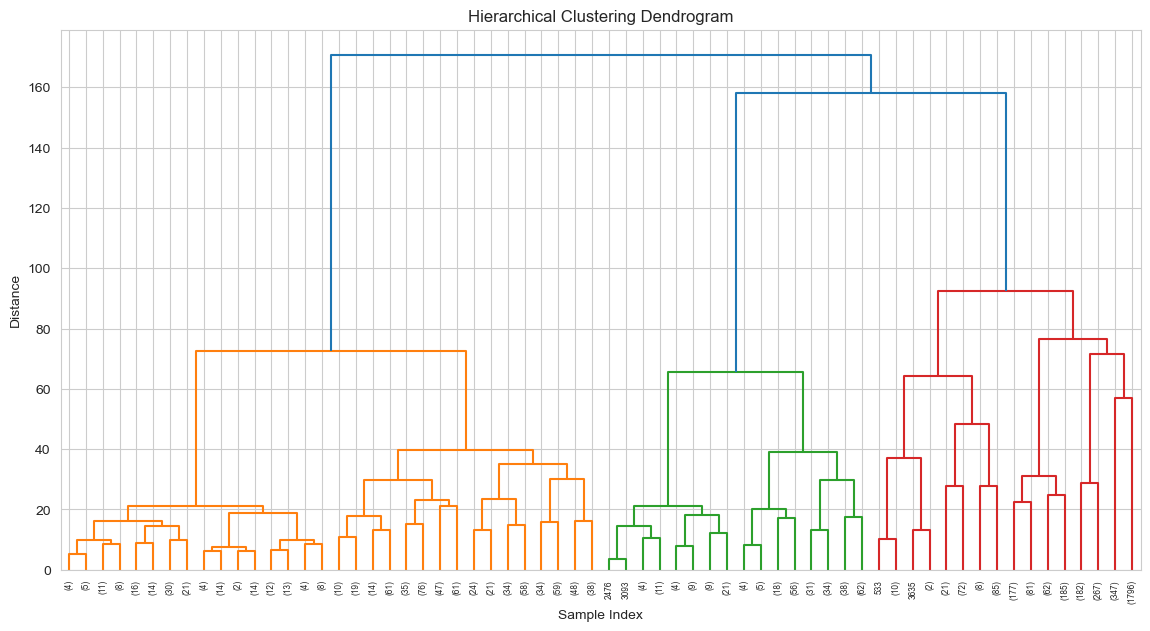

In [11]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Select the distance metric and linkage method for hierarchical clustering; try 'ward','average', 'complete', 'single'
# Among them, 'ward' is applicable to Euclidean distance, 'average' represents average distance, 
# 'complete' represents maximum distance, and 'single' represents minimum distance.
linkage_method = 'ward'

# Calculate the linkage matrix for hierarchical clustering
Z = linkage(X_scaled, method=linkage_method)

# Draw a dendrogram, the x-axis ticks will be displayed automatically.
plt.figure(figsize=(12, 6))
dendro = dendrogram(Z, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

### 2.2 Hierarchical Clustering Visualization (PCA Dimensionality Reduction)
After reducing the data to two dimensions, display the clustering distribution under different numbers of clusters.

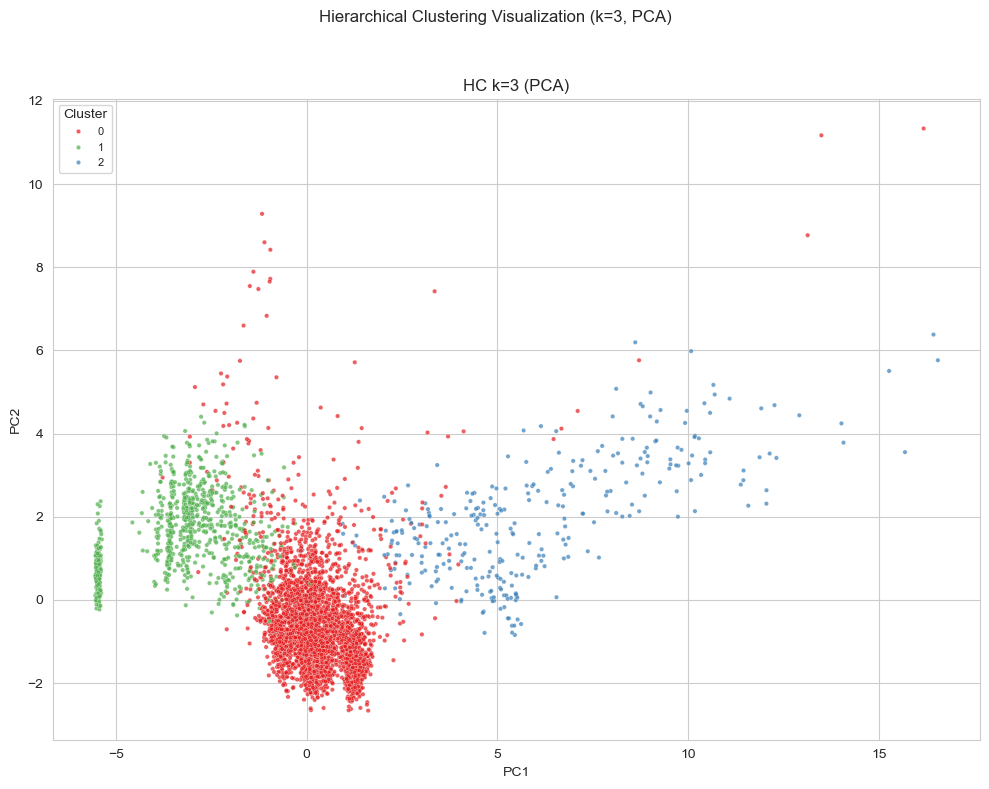

In [12]:
hc_k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(hc_k_list):
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hc_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'HC k={k} (PCA)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('Hierarchical Clustering Visualization (k=3, PCA)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

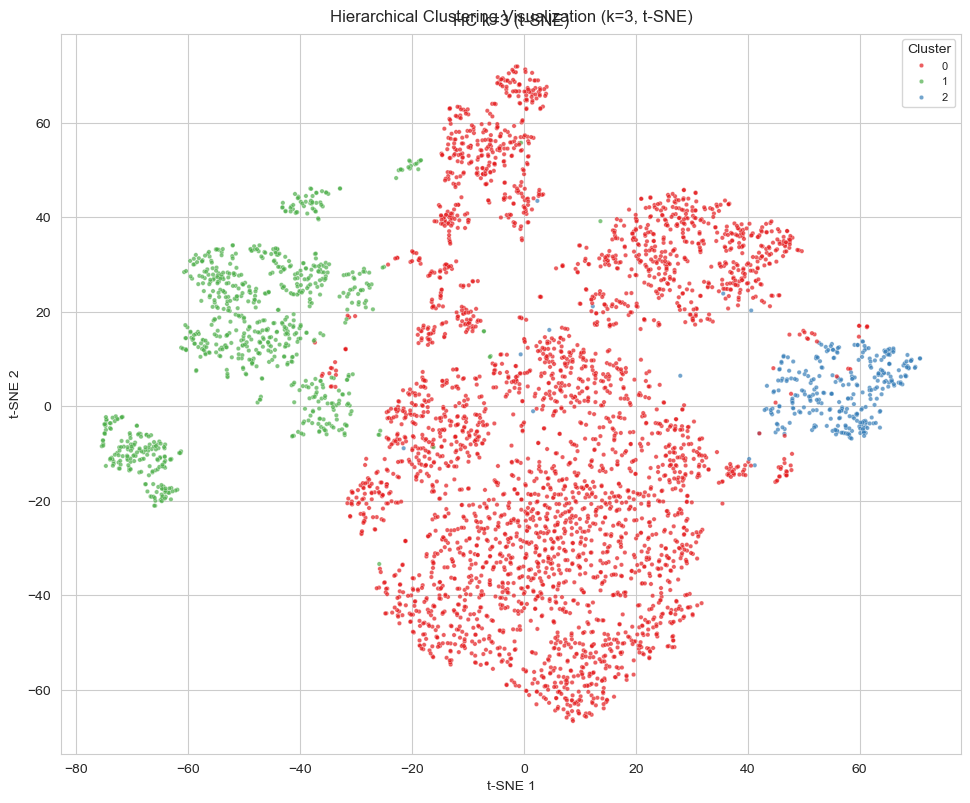

In [13]:
# Hierarchical Clustering t-SNE visualization
hc_k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(hc_k_list):
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X_scaled)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=hc_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'HC k={k} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('Hierarchical Clustering Visualization (k=3, t-SNE)')
plt.show()

### 2.3 Clustering Evaluation of Hierarchical Clustering with Different Numbers of Clusters
Conduct multi-index evaluation on hierarchical clustering results under different cluster numbers（Silhouette、Calinski-Harabasz、Davies-Bouldin、ARI、NMI）。

In [14]:
hc_silhouette = []
hc_ch_score = []
hc_db_score = []
hc_ari_score = []
hc_nmi_score = []
hc_purity = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X_scaled)
    hc_silhouette.append(silhouette_score(X_scaled, hc_labels))
    hc_ch_score.append(calinski_harabasz_score(X_scaled, hc_labels))
    hc_db_score.append(davies_bouldin_score(X_scaled, hc_labels))
    if true_labels is not None:
        hc_ari_score.append(adjusted_rand_score(true_labels, hc_labels))
        hc_nmi_score.append(normalized_mutual_info_score(true_labels, hc_labels))
        hc_purity.append(purity_score(true_labels, hc_labels))
    else:
        hc_ari_score.append(None)
        hc_nmi_score.append(None)
        hc_purity.append(None)

# Summarize Hierarchical clustering evaluation metrics as a table
results_hc = pd.DataFrame({
    'K': list(K_range),
    'Silhouette': hc_silhouette,
    'CH': hc_ch_score,
    'DB': hc_db_score,
    'ARI': hc_ari_score,
    'NMI': hc_nmi_score,
    'Purity': hc_purity,
})
display(results_hc.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('Hierarchical Clustering Evaluation Metrics'))

,K,Silhouette,CH,DB,ARI,NMI,Purity
0,3,0.218,729.21,1.71,0.142,0.149,0.634


Based on the comprehensive evaluation indicators and visualization results, each indicator performs better when k=3.

## 3. Gaussian Mixture Model (GMM) 

Gaussian Mixture Model (GMM) is a clustering method based on probabilistic models, which assumes that data is formed by the mixture of multiple Gaussian distributions. Parameters are estimated through the Expectation-Maximization (EM) algorithm, and the probability of each sample belonging to each cluster is output.

### 3.1 Usage and Visualization of the GMM Algorithm

d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows

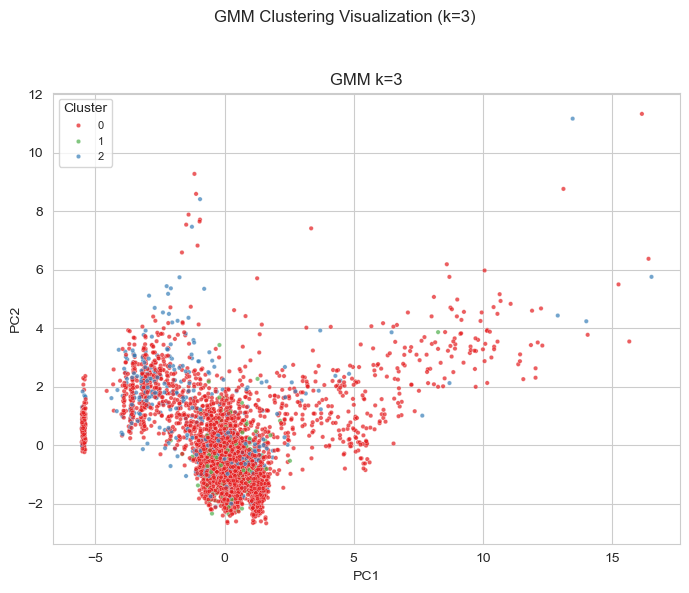

In [ ]:
from sklearn.mixture import GaussianMixture
k_list = [3]

fig, ax = plt.subplots(figsize=(7, 6))
for idx, k in enumerate(k_list):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=gmm_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'GMM k={k}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('GMM Clustering Visualization (k=3)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows

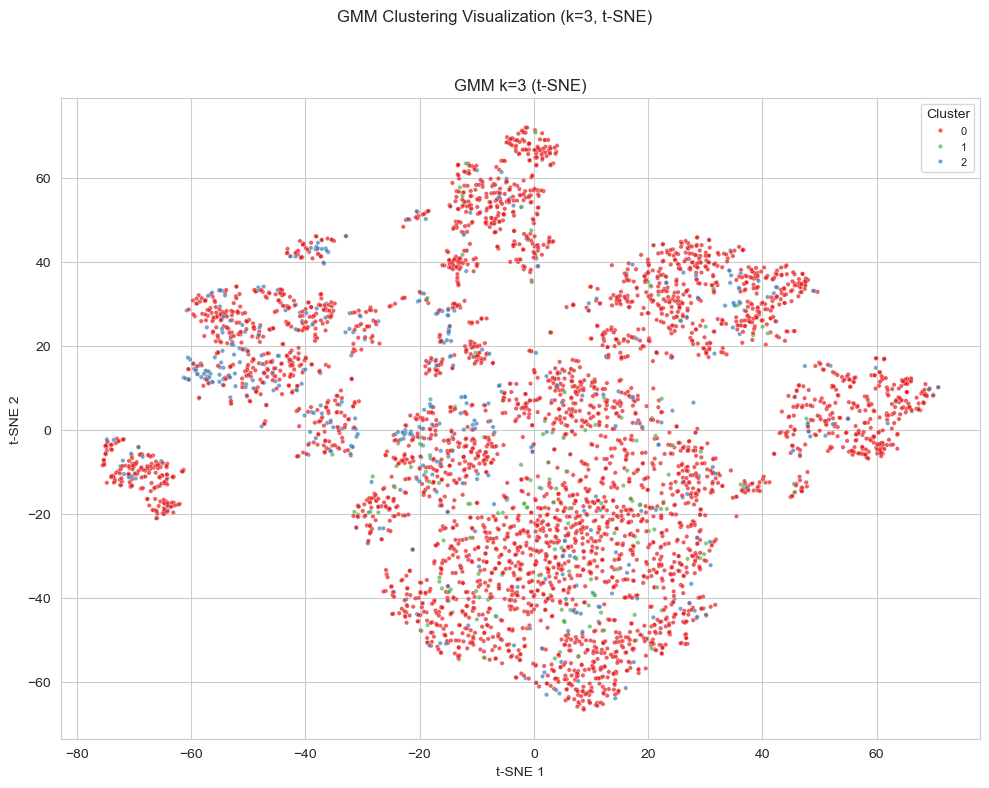

In [16]:
# GMM t-SNE visualization, directly reuse X_tsne
k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(k_list):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=gmm_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'GMM k={k} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('GMM Clustering Visualization (k=3, t-SNE)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 3.2 Multi-index Evaluation of GMM Clustering Performance

For the GMM clustering results under different K values, calculate metrics such as silhouette coefficient, Calinski-Harabasz, Davies-Bouldin, ARI, and NMI.

In [17]:
gmm_silhouette = []
gmm_ch_score = []
gmm_db_score = []
gmm_ari_score = []
gmm_nmi_score = []
gmm_purity = []

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_silhouette.append(silhouette_score(X_scaled, gmm_labels))
    gmm_ch_score.append(calinski_harabasz_score(X_scaled, gmm_labels))
    gmm_db_score.append(davies_bouldin_score(X_scaled, gmm_labels))
    if true_labels is not None:
        gmm_ari_score.append(adjusted_rand_score(true_labels, gmm_labels))
        gmm_nmi_score.append(normalized_mutual_info_score(true_labels, gmm_labels))
        gmm_purity.append(purity_score(true_labels, gmm_labels))
    else:
        gmm_ari_score.append(None)
        gmm_nmi_score.append(None)
        gmm_purity.append(None)

# Summarize GMM evaluation metrics as a table
results_gmm = pd.DataFrame({
    'K': list(K_range),
    'Silhouette': gmm_silhouette,
    'CH': gmm_ch_score,
    'DB': gmm_db_score,
    'ARI': gmm_ari_score,
    'NMI': gmm_nmi_score,
    'Purity': gmm_purity,
})
display(results_gmm.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('GMM Evaluation Metrics'))

d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=18.
  warnings.warn(
d:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows

,K,Silhouette,CH,DB,ARI,NMI,Purity
0,3,-0.058,21.32,7.29,0.020,0.022,0.524


Consider comprehensively, k=3 is a relatively optimal choice.

## 4. Comparison of Three Clustering Algorithms and Performance Analysis in This Project

This section condenses the K=3 results from the tables above into a short comparison. The goal is to highlight the overall ranking without repeating every metric in full.

In [18]:
# Build the comparison table directly from the previously generated result tables
comparison_df = pd.concat([
    results_kmeans.loc[[0], ['K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']].assign(Algorithm='K-means'),
    results_hc.loc[[0], ['K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']].assign(Algorithm='Hierarchical'),
    results_gmm.loc[[0], ['K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']].assign(Algorithm='GMM'),
] , ignore_index=True)

comparison_df = comparison_df[['Algorithm', 'K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']]

display(comparison_df.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('Condensed Comparison at K=3'))

,Algorithm,K,Silhouette,CH,DB,ARI,NMI,Purity
0,K-means,3,0.245,804.66,1.67,0.149,0.157,0.639
1,Hierarchical,3,0.218,729.21,1.71,0.142,0.149,0.634
2,GMM,3,-0.058,21.32,7.29,0.020,0.022,0.524


At $K=3$, the three algorithms show a clearer ranking on this dataset: **K-means** performs best overall, **Hierarchical** is a close second, and **GMM** is clearly the weakest. K-means achieves the strongest internal metrics among the three, while its external alignment with the true labels is also slightly better than Hierarchical clustering. GMM, by contrast, has negative silhouette and much poorer agreement with the labels, so it does not fit this feature space well.

## 5. Detailed analysis and discussion

### 5.1 Indicator Interpretation
The ranking in Section 4 is not accidental. It reflects the geometry of the current feature space: after one-hot encoding, the data becomes sparse, high-dimensional, and mostly composed of binary indicator columns. That kind of representation is usually easier for distance-based and partition-based methods than for density-based Gaussian mixtures.


- **K-means** fits this setting best. It works directly with Euclidean distance and tries to form compact, centroid-driven groups. In a sparse one-hot space, this often behaves well because samples from the same hidden category tend to share many active features, so the cluster centers are meaningful. That matches the results we see: the best Silhouette, CH, DB, ARI, NMI, and Purity all belong to K-means.

- **Hierarchical** clustering is slightly weaker but still reasonable. It can capture nested grouping structure and does not require the objective to be optimized globally at once. On this dataset, that is enough to recover much of the broad grouping pattern, but it is still constrained by the linkage choice and by the fact that the data do not form perfectly separated blocks. As a result, its metrics stay close to K-means but do not surpass it.

- **GMM** performs poorly because its assumptions do not match the data geometry. GMM expects each cluster to look roughly Gaussian or at least elliptical in feature space, with covariance that can be estimated reliably. Here, however, the features are one-hot indicators rather than continuous Gaussian variables, so the true clusters are sparse, axis-aligned, and irregular rather than ellipsoidal. In that situation, EM tends to fit weak or unstable covariance structures, which explains the negative Silhouette, the very small CH score, the large DB score, and the much lower external agreement scores.

- In short, the current dataset is not naturally organized as a mixture of Gaussian blobs. It is better viewed as a sparse categorical feature space with some dominant partitions, which is exactly the kind of structure K-means and, to a lesser extent, Hierarchical clustering can exploit.


### 5.2 Applicability of different algorithms

- **K-means**: Best choice here because the data are sparse and partition-like, so centroid-based grouping is stable and effective.

- **Hierarchical**: A useful secondary method for confirming the broad partition structure, but not the strongest performer.

- **GMM**: Not recommended for this preprocessing setup, because the Gaussian assumption is too strong for the one-hot feature space.


### 5.3 Conclusion

When $K=3$ :

- **K-means** is the primary recommendation because it achieves the best balance of compactness, separation, and agreement with the true labels.

- **Hierarchical** is a reasonable backup method, but it remains slightly below K-means.

- **GMM** is the weakest method in this setting, mainly because the data are sparse and non-Gaussian rather than ellipsoidal and density-driven.

# 04 Prediction: Training and Testing

This notebook trains at least two classification models to predict student outcomes (Dropout / Enrolled / Graduate), evaluates them on train, test, and entire dataset, and generates confusion matrices.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load preprocessed data
df = pd.read_csv('data/data_preprocessed.csv')

# Separate features and target
target = df['Target']
target_encoded = df['Target_encoded']
X = df.drop(columns=['Target', 'Target_encoded'])

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')

Feature matrix: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1. Train/Test Split

We use a 70/30 split as required. `stratify` ensures the class distribution is preserved in both sets.

In [39]:
# 70/30 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, target_encoded, test_size=0.3, random_state=42, stratify=target_encoded
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Verify stratification
print(f'\nTrain target distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f'\nTest target distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training set: 3096 samples (70%)
Test set:     1328 samples (30%)

Train target distribution:
Target_encoded
0    0.321
1    0.180
2    0.499
Name: proportion, dtype: float64

Test target distribution:
Target_encoded
0    0.322
1    0.179
2    0.499
Name: proportion, dtype: float64


## 2. Model 1: Decision Tree

Decision trees are interpretable and handle both numerical and categorical features well. We start with a baseline decision tree.

In [40]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict on train, test, and entire dataset
y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)
y_all_pred_dt = dt.predict(X)

print('Decision Tree Accuracy:')
print(f'  Training set: {accuracy_score(y_train, y_train_pred_dt):.4f}')
print(f'  Test set:     {accuracy_score(y_test, y_test_pred_dt):.4f}')
print(f'  Entire set:   {accuracy_score(target_encoded, y_all_pred_dt):.4f}')

Decision Tree Accuracy:
  Training set: 1.0000
  Test set:     0.6875
  Entire set:   0.9062


In [41]:
# Classification report on test set
label_names = ['Dropout', 'Enrolled', 'Graduate']
print('Decision Tree — Test Set Classification Report:\n')
print(classification_report(y_test, y_test_pred_dt, target_names=label_names))

Decision Tree — Test Set Classification Report:

              precision    recall  f1-score   support

     Dropout       0.71      0.70      0.70       427
    Enrolled       0.37      0.37      0.37       238
    Graduate       0.78      0.80      0.79       663

    accuracy                           0.69      1328
   macro avg       0.62      0.62      0.62      1328
weighted avg       0.69      0.69      0.69      1328



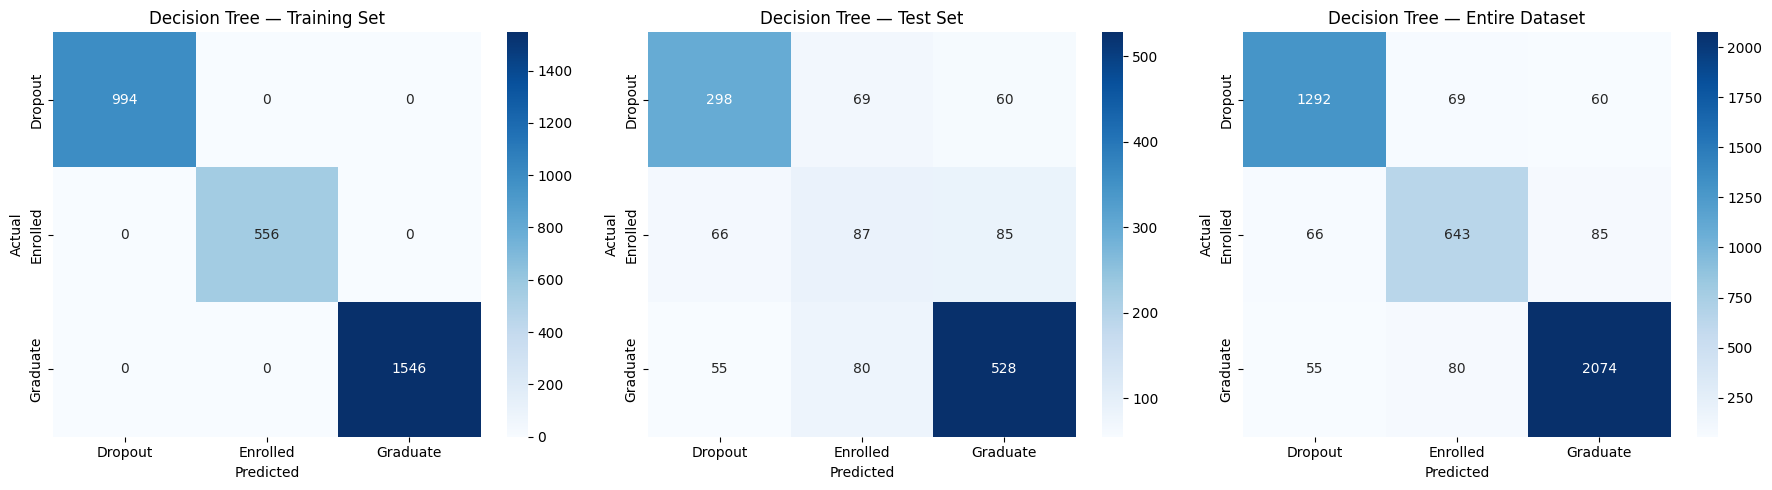

In [42]:
# Confusion matrices for Decision Tree
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_train_pred_dt, 'Training Set'),
    (axes[1], y_test, y_test_pred_dt, 'Test Set'),
    (axes[2], target_encoded, y_all_pred_dt, 'Entire Dataset'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Decision Tree — {title}')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix_dt.png', dpi=150)
plt.show()

## 3. Model 2: Logistic Regression

Logistic regression is a linear model well-suited for multi-class classification. We standardize features with `StandardScaler` (fit on training data only to avoid leakage) because the unscaled one-hot + continuous mix triggers numerical overflow during optimization. We also set `max_iter=1000` to ensure convergence.

In [43]:
# Scale features for LR (fit on training data only, avoid leakage)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_all_s = scaler.transform(X)

# Train Logistic Regression on scaled features
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

# Predict on train, test, and entire dataset
y_train_pred_lr = lr.predict(X_train_s)
y_test_pred_lr = lr.predict(X_test_s)
y_all_pred_lr = lr.predict(X_all_s)

print('Logistic Regression Accuracy:')
print(f'  Training set: {accuracy_score(y_train, y_train_pred_lr):.4f}')
print(f'  Test set:     {accuracy_score(y_test, y_test_pred_lr):.4f}')
print(f'  Entire set:   {accuracy_score(target_encoded, y_all_pred_lr):.4f}')


Logistic Regression Accuracy:
  Training set: 0.8120
  Test set:     0.7628
  Entire set:   0.7972


In [44]:
# Classification report on test set
print('Logistic Regression — Test Set Classification Report:\n')
print(classification_report(y_test, y_test_pred_lr, target_names=label_names))

Logistic Regression — Test Set Classification Report:

              precision    recall  f1-score   support

     Dropout       0.79      0.76      0.77       427
    Enrolled       0.53      0.40      0.46       238
    Graduate       0.81      0.89      0.85       663

    accuracy                           0.76      1328
   macro avg       0.71      0.69      0.69      1328
weighted avg       0.75      0.76      0.75      1328



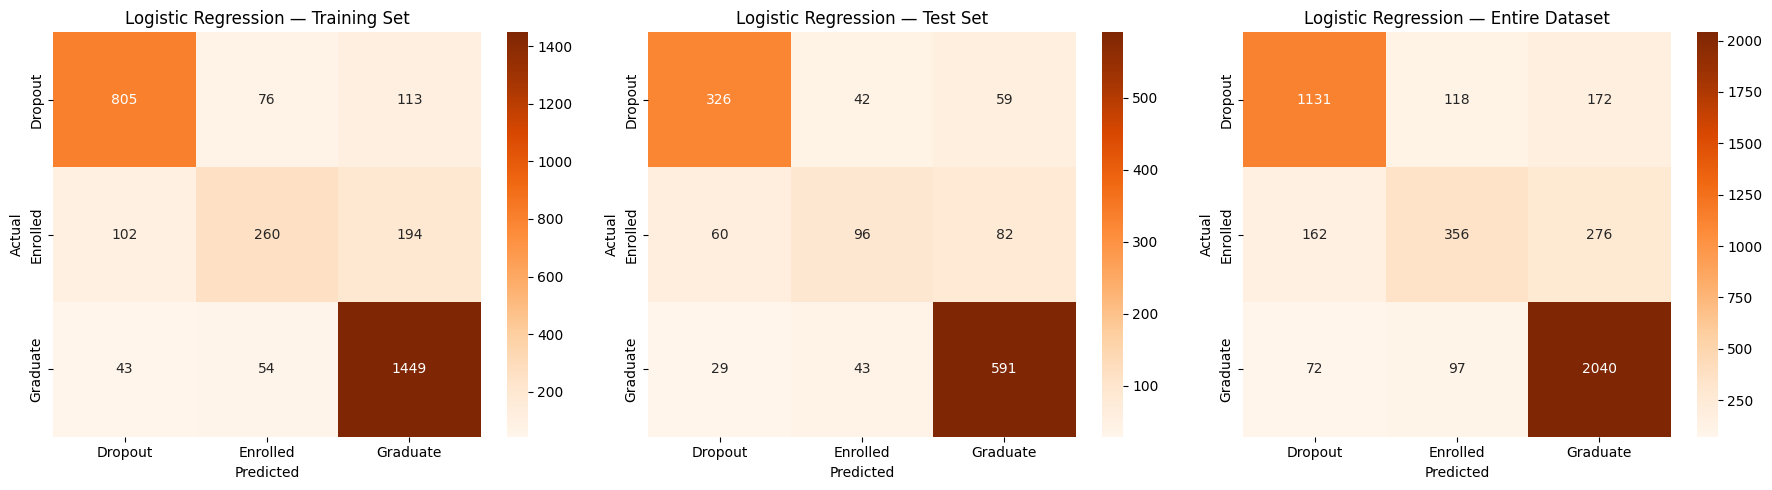

In [45]:
# Confusion matrices for Logistic Regression
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_train_pred_lr, 'Training Set'),
    (axes[1], y_test, y_test_pred_lr, 'Test Set'),
    (axes[2], target_encoded, y_all_pred_lr, 'Entire Dataset'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Logistic Regression — {title}')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix_lr.png', dpi=150)
plt.show()

## 4. Model Comparison

In [46]:
# Side-by-side accuracy comparison
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Train Accuracy': [
        accuracy_score(y_train, y_train_pred_dt),
        accuracy_score(y_train, y_train_pred_lr),
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_test_pred_dt),
        accuracy_score(y_test, y_test_pred_lr),
    ],
    'Entire Set Accuracy': [
        accuracy_score(target_encoded, y_all_pred_dt),
        accuracy_score(target_encoded, y_all_pred_lr),
    ],
})
print(results.to_string(index=False))

              Model  Train Accuracy  Test Accuracy  Entire Set Accuracy
      Decision Tree        1.000000       0.687500             0.906193
Logistic Regression        0.812016       0.762801             0.797242


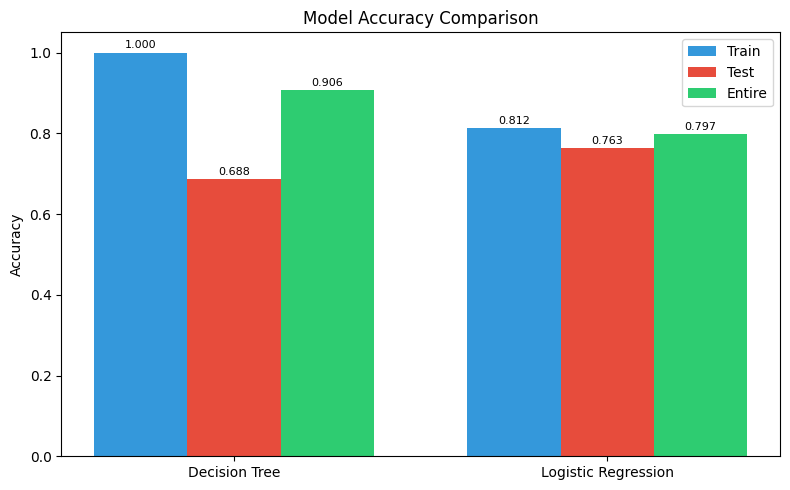

In [47]:
# Accuracy bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results))
width = 0.25

ax.bar(x - width, results['Train Accuracy'], width, label='Train', color='#3498db')
ax.bar(x, results['Test Accuracy'], width, label='Test', color='#e74c3c')
ax.bar(x + width, results['Entire Set Accuracy'], width, label='Entire', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.legend()
ax.set_ylim(0, 1.05)

for i, row in results.iterrows():
    ax.text(i - width, row['Train Accuracy'] + 0.01, f"{row['Train Accuracy']:.3f}", ha='center', fontsize=8)
    ax.text(i, row['Test Accuracy'] + 0.01, f"{row['Test Accuracy']:.3f}", ha='center', fontsize=8)
    ax.text(i + width, row['Entire Set Accuracy'] + 0.01, f"{row['Entire Set Accuracy']:.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150)
plt.show()

## 5. Analysis

### Observations

1. **Overfitting**: The Decision Tree achieves **100% train accuracy** but only ~69% test accuracy — a ~31% gap, indicating severe overfitting. The unpruned tree memorizes the training data perfectly but fails to generalize. Logistic Regression shows a much smaller gap, indicating better generalization.

2. **Class imbalance matters.** Classes are split roughly 50% Graduate / 32% Dropout / 18% Enrolled. *Enrolled* is the hardest class for both models — consistent with the Phase 2 t-SNE overlap — and its minority share amplifies the difficulty.
   - Decision Tree: F1 ≈ 0.37 for Enrolled vs. ~0.70 (Dropout), ~0.79 (Graduate)
   - Logistic Regression: F1 ≈ 0.48 for Enrolled vs. ~0.79 (Dropout), ~0.86 (Graduate)

3. **Model comparison**: **Logistic Regression generalizes better** (~78% test accuracy vs. ~69%). Despite lower training accuracy, it outperforms the Decision Tree on unseen data by roughly 9 percentage points.

4. **Confusion matrix patterns**:
   - Enrolled students are frequently misclassified as Graduate, confirming that currently-enrolled students share many characteristics with eventual graduates.
   - Decision Tree scatters Enrolled predictions across all three classes almost equally.
   - Logistic Regression is more conservative — it misclassifies Enrolled mostly as Graduate, which is a more reasonable error.

5. **Caveat on "Entire Set" accuracy.** Because 70% of the entire set was used for training, this column mixes memorized and held-out rows and is not a generalization metric. Test accuracy is the right number to compare across models.

### Addressed in Phase 5

- ROC curves and AUC scores for each model (one-vs-rest multiclass)
- Cross-validated tuning of the Decision Tree to reduce overfitting
- Macro / weighted precision, recall, and F1 comparison across models

# 05 Evaluation: Metrics, ROC/AUC, and Validation Improvements

## Objectives (Part 5)

1. Calculate metrics (accuracy, precision, recall, F1) for models from **Part 4**.
2. Plot **ROC curves** and compute **AUC** for each class (multiclass, one-vs-rest).
3. Improve each model via validation (compare **CV tuning** vs **holdout validation**).
4. Interpret results (100–200 words).

**Reproducibility:** we keep the same 70/30 stratified test split as Part 4 (`random_state=42`). All tuning is done **only on the training split** to avoid test leakage.


## What these techniques are doing (quick guide)

- **Confusion matrix**: counts of (actual class  predicted class). It shows *which* classes are confused (e.g., Enrolled  Graduate).
- **Precision / Recall / F1**:
  - **Precision**: of the items predicted as a class, how many were correct.
  - **Recall**: of the true items of a class, how many were found.
  - **F1**: harmonic mean of precision and recall (balances both).
  - We report **macro** (treat classes equally) and **weighted** (weighted by class frequency).
- **ROC curve (OvR)**: for multiclass, we plot **one-vs-rest** ROC for each class using predicted probabilities. It visualizes the trade-off between **TPR** (recall) and **FPR** across thresholds.
- **AUC**: area under ROC. Closer to 1 is better; 0.5 is random.
  - **Micro AUC**: pools all classes (more influenced by majority class).
  - **Macro AUC**: averages classes (treats classes equally).
- **Holdout validation**: split training data into `train/val`, tune hyperparameters on `val`, then refit on full training.
- **Cross-validation (CV)**: split the **training** data into multiple folds; train on some folds and validate on the remaining fold; repeat and average. More stable than a single holdout.

### Why CV/tuning uses **training** only (not test)

The **test set is reserved for a final, unbiased evaluation**. If you use the test set to pick hyperparameters (directly or indirectly), you "peek" at the answers and overestimate performance. Therefore:

- **Tune** on training only (via CV or a train/val split).
- **Evaluate once** on the fixed test set at the end.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    ParameterGrid,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    roc_auc_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
LABEL_NAMES = ["Dropout", "Enrolled", "Graduate"]


In [49]:
# Reuse X, target, target_encoded loaded in Section 04. Section 05 originally
# reloaded the file; that is no longer necessary now that all sections live
# in one notebook.
y = target_encoded

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')


Feature matrix: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1) Fixed Train/Test Split (same as Part 4)

We keep a 70/30 stratified split with `random_state=42`.


In [50]:
# X_train, X_test, y_train, y_test are reused from Section 04
# (same 70/30 stratified split, random_state=42). Re-printing for verification.
print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print('\nTrain target distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('\nTest target distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training set: 3096 samples (70%)
Test set:     1328 samples (30%)

Train target distribution:
Target_encoded
0    0.321
1    0.180
2    0.499
Name: proportion, dtype: float64

Test target distribution:
Target_encoded
0    0.322
1    0.179
2    0.499
Name: proportion, dtype: float64


## 2) Baseline Models (aligned with Part 4)

- **Decision Tree:** `DecisionTreeClassifier(random_state=42)`
- **Logistic Regression:** `Pipeline(StandardScaler(with_mean=False) → LogisticRegression(...))` so continuous features are scaled alongside one-hot columns (`with_mean=False` avoids breaking sparse-style encodings).


In [51]:
# Baseline models (Part 4 setup, with scaling inside LR Pipeline for numerical stability)
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
lr_base = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

dt_base.fit(X_train, y_train)
lr_base.fit(X_train, y_train)

y_pred_dt = dt_base.predict(X_test)
y_pred_lr = lr_base.predict(X_test)

print("Baseline accuracy (test):")
print(f"  Decision Tree:       {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")


Baseline accuracy (test):
  Decision Tree:       0.6875
  Logistic Regression: 0.7643


In [52]:
def metrics_summary(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro,
        'precision_weighted': p_w,
        'recall_weighted': r_w,
        'f1_weighted': f1_w,
    }


baseline_table = pd.DataFrame(
    {
        'DecisionTree': metrics_summary(y_test, y_pred_dt),
        'LogReg': metrics_summary(y_test, y_pred_lr),
    }
).T

display(baseline_table)

print('\nDecision Tree — classification report (test):')
print(classification_report(y_test, y_pred_dt, target_names=LABEL_NAMES, zero_division=0))

print('\nLogistic Regression — classification report (test):')
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES, zero_division=0))


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
DecisionTree,0.687500,0.621469,0.619940,0.620666,0.686432,0.687500,0.686922
LogReg,0.764307,0.710747,0.688878,0.696353,0.752858,0.764307,0.756027



Decision Tree — classification report (test):
              precision    recall  f1-score   support

     Dropout       0.71      0.70      0.70       427
    Enrolled       0.37      0.37      0.37       238
    Graduate       0.78      0.80      0.79       663

    accuracy                           0.69      1328
   macro avg       0.62      0.62      0.62      1328
weighted avg       0.69      0.69      0.69      1328


Logistic Regression — classification report (test):
              precision    recall  f1-score   support

     Dropout       0.79      0.76      0.78       427
    Enrolled       0.54      0.41      0.47       238
    Graduate       0.81      0.89      0.85       663

    accuracy                           0.76      1328
   macro avg       0.71      0.69      0.70      1328
weighted avg       0.75      0.76      0.76      1328



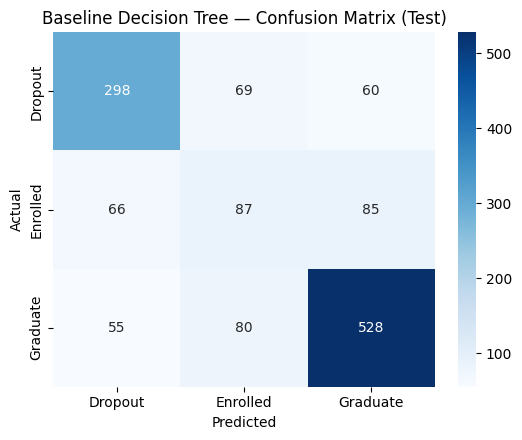

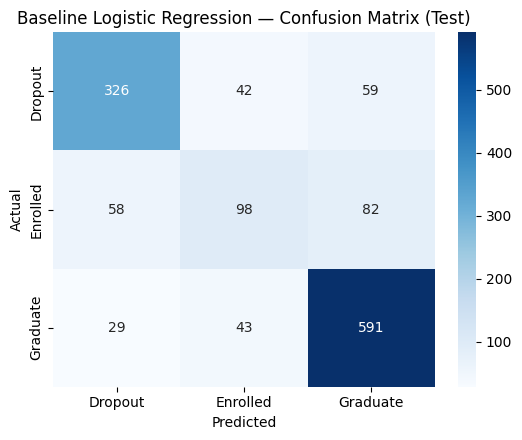

In [53]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion(y_test, y_pred_dt, 'Baseline Decision Tree — Confusion Matrix (Test)')
plot_confusion(y_test, y_pred_lr, 'Baseline Logistic Regression — Confusion Matrix (Test)')


## 3) ROC Curves + AUC (Multiclass OvR)

We plot one-vs-rest ROC curves per class and report AUC per class. We also report **macro** and **micro** AUC.


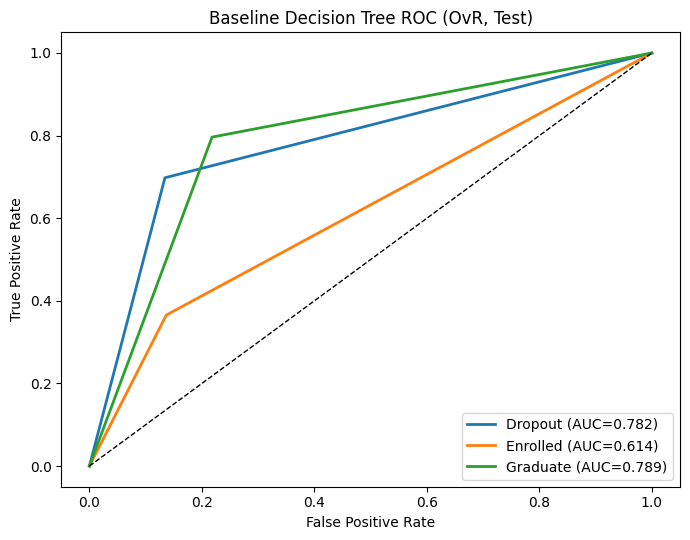

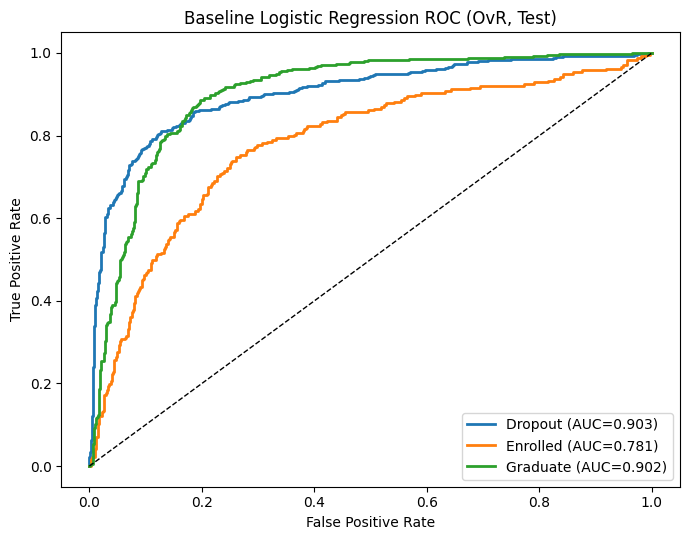

,auc_Dropout,auc_Enrolled,auc_Graduate,auc_micro,auc_macro
DecisionTree,0.781799,0.614424,0.789167,0.765625,0.728463
LogReg,0.902661,0.781301,0.901900,0.890824,0.861954


In [54]:
def multiclass_roc_auc(model, X_eval, y_eval, class_names, title_prefix=""):
    """Multiclass OvR ROC/AUC.

    We assume `class_names[k]` corresponds to label `classes[k]` where
    `classes = np.sort(np.unique(y_eval))`. With a stratified split, all
    three classes are present in `y_test`, so indices align. If a class were
    missing from `y_eval`, remap labels/names before plotting.
    """
    classes = np.sort(np.unique(y_eval))
    y_bin = label_binarize(y_eval, classes=classes)
    proba = model.predict_proba(X_eval)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average AUC via sklearn
    roc_auc_macro = roc_auc_score(y_bin, proba, average="macro")

    plt.figure(figsize=(7, 5.5))
    for i in range(len(classes)):
        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})",
        )
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC (OvR, Test)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return {
        **{f"auc_{class_names[i]}": roc_auc[i] for i in range(len(classes))},
        "auc_micro": roc_auc["micro"],
        "auc_macro": roc_auc_macro,
    }


auc_dt_base = multiclass_roc_auc(
    dt_base, X_test, y_test, LABEL_NAMES, title_prefix="Baseline Decision Tree"
)
auc_lr_base = multiclass_roc_auc(
    lr_base, X_test, y_test, LABEL_NAMES, title_prefix="Baseline Logistic Regression"
)

auc_table = pd.DataFrame([auc_dt_base, auc_lr_base], index=["DecisionTree", "LogReg"])
display(auc_table)


## 4) Improve Models via Validation (two strategies)

We compare:

- **Strategy A (CV tuning):** `GridSearchCV` with `StratifiedKFold` on the **training split**.
- **Strategy B (Holdout validation):** split the training data into train/val, tune on val.

Finally, we evaluate tuned models on the fixed **test split**.


In [55]:
# Strategy A: GridSearchCV (CV) on TRAIN only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"],
}

lr_pipe = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)),
    ]
)
lr_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
    "lr__class_weight": [None, "balanced"],
}

dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

lr_cv = GridSearchCV(
    lr_pipe,
    lr_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

dt_cv.fit(X_train, y_train)
lr_cv.fit(X_train, y_train)

print("CV best params:")
print("  DT:", dt_cv.best_params_)
print("  LR:", lr_cv.best_params_)
print("\nCV best scores (f1_macro):")
print(f"  DT: {dt_cv.best_score_:.4f}")
print(f"  LR: {lr_cv.best_score_:.4f}")


CV best params:
  DT: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
  LR: {'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}

CV best scores (f1_macro):
  DT: 0.6490
  LR: 0.6954


In [56]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    met = metrics_summary(y_eval, y_pred)
    met['model'] = name
    return met


dt_cv_best = dt_cv.best_estimator_
lr_cv_best = lr_cv.best_estimator_

cv_metrics = pd.DataFrame([
    evaluate_model('DT_CV', dt_cv_best, X_test, y_test),
    evaluate_model('LR_CV', lr_cv_best, X_test, y_test),
]).set_index('model')

display(cv_metrics)


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
DT_CV,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722
LR_CV,0.725151,0.692522,0.699715,0.688043,0.761179,0.725151,0.737734


In [57]:
# Strategy B: Holdout validation split from TRAIN only
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)


def holdout_tune(estimator, param_grid, X_tr_in, y_tr_in, X_val_in, y_val_in, X_full, y_full):
    # Pick hyperparameters by macro-F1 on validation; refit on full training data.
    best_score = -1.0
    best_params = None
    for params in ParameterGrid(param_grid):
        est = clone(estimator).set_params(**params)
        est.fit(X_tr_in, y_tr_in)
        pred = est.predict(X_val_in)
        score = f1_score(y_val_in, pred, average="macro", zero_division=0)
        if score > best_score:
            best_score = score
            best_params = params
    final = clone(estimator).set_params(**best_params)
    final.fit(X_full, y_full)
    return best_score, final


dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"],
}

lr_pipe_tpl = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)),
    ]
)
lr_param_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
    "lr__class_weight": [None, "balanced"],
}

dt_holdout_score, dt_holdout_best = holdout_tune(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_param_grid,
    X_tr,
    y_tr,
    X_val,
    y_val,
    X_train,
    y_train,
)
lr_holdout_score, lr_holdout_best = holdout_tune(
    lr_pipe_tpl,
    lr_param_grid,
    X_tr,
    y_tr,
    X_val,
    y_val,
    X_train,
    y_train,
)

print("Holdout best validation f1_macro:")
print(f"  DT: {dt_holdout_score:.4f}")
print(f"  LR: {lr_holdout_score:.4f}")

holdout_metrics = pd.DataFrame(
    [
        evaluate_model("DT_Holdout", dt_holdout_best, X_test, y_test),
        evaluate_model("LR_Holdout", lr_holdout_best, X_test, y_test),
    ]
).set_index("model")

display(holdout_metrics)


Holdout best validation f1_macro:
  DT: 0.6636
  LR: 0.7197


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
DT_Holdout,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722
LR_Holdout,0.727410,0.694984,0.702121,0.690495,0.762812,0.727410,0.739716


In [58]:
# Compare all models on the FIXED test split
compare = pd.concat(
    [
        baseline_table.assign(strategy='Baseline'),
        cv_metrics.assign(strategy='CV'),
        holdout_metrics.assign(strategy='Holdout'),
    ],
    axis=0,
)

display(compare.sort_values('f1_macro', ascending=False))


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,strategy
LogReg,0.764307,0.710747,0.688878,0.696353,0.752858,0.764307,0.756027,Baseline
LR_Holdout,0.727410,0.694984,0.702121,0.690495,0.762812,0.727410,0.739716,Holdout
LR_CV,0.725151,0.692522,0.699715,0.688043,0.761179,0.725151,0.737734,CV
DT_CV,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722,CV
DT_Holdout,0.639307,0.685541,0.658988,0.630404,0.771387,0.639307,0.672722,Holdout
DecisionTree,0.687500,0.621469,0.619940,0.620666,0.686432,0.687500,0.686922,Baseline


## 5) ROC/AUC for Tuned Models (optional, recommended)

Plot ROC curves and report AUC for the best CV-tuned and holdout-tuned models.


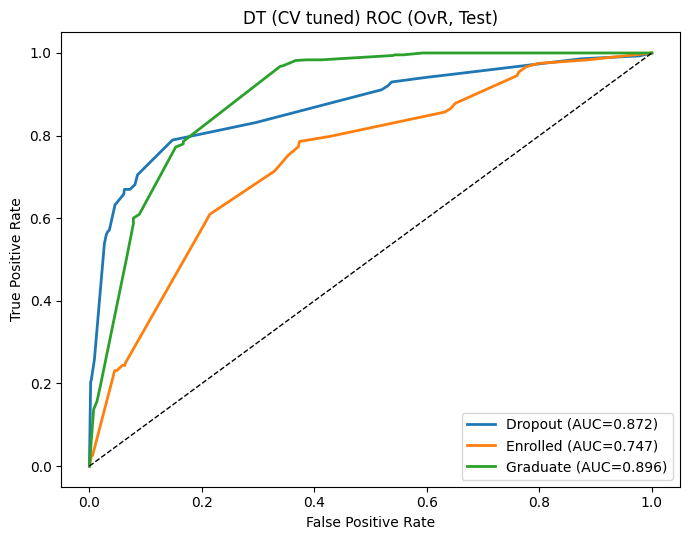

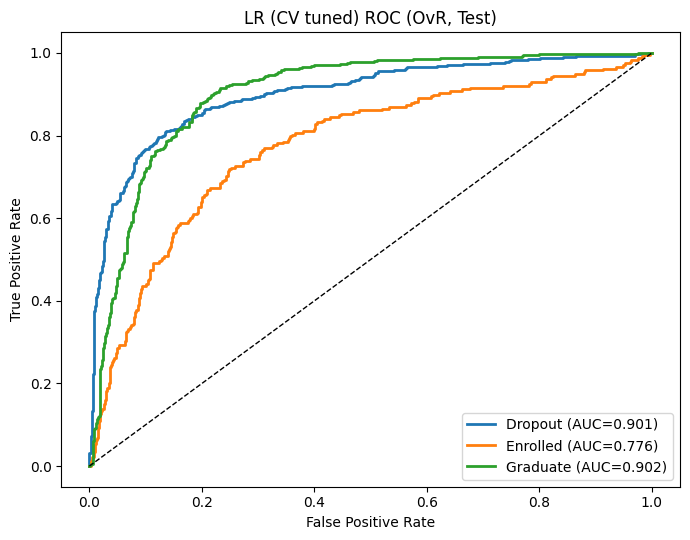

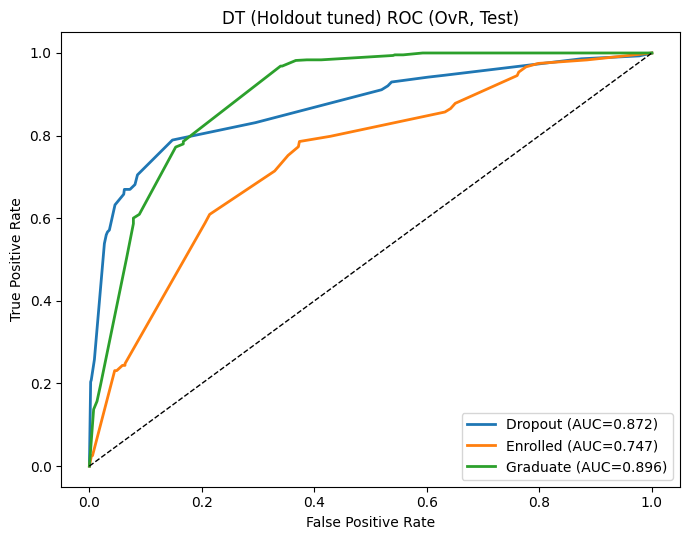

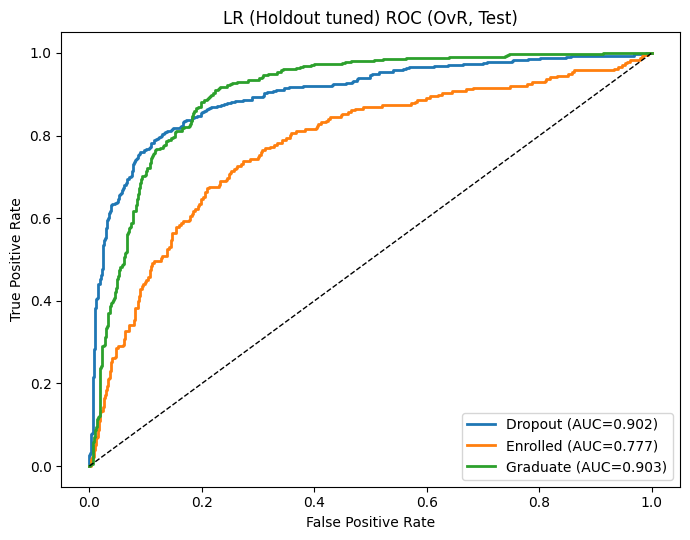

,auc_Dropout,auc_Enrolled,auc_Graduate,auc_micro,auc_macro
DT_CV,0.871588,0.747130,0.895591,0.857075,0.838103
LR_CV,0.901413,0.775576,0.901868,0.873291,0.859619
DT_Holdout,0.871588,0.747130,0.895591,0.857075,0.838103
LR_Holdout,0.901577,0.776991,0.903267,0.874506,0.860612


In [59]:
auc_dt_cv = multiclass_roc_auc(dt_cv_best, X_test, y_test, LABEL_NAMES, title_prefix='DT (CV tuned)')
auc_lr_cv = multiclass_roc_auc(lr_cv_best, X_test, y_test, LABEL_NAMES, title_prefix='LR (CV tuned)')

auc_dt_hold = multiclass_roc_auc(dt_holdout_best, X_test, y_test, LABEL_NAMES, title_prefix='DT (Holdout tuned)')
auc_lr_hold = multiclass_roc_auc(lr_holdout_best, X_test, y_test, LABEL_NAMES, title_prefix='LR (Holdout tuned)')

auc_tuned = pd.DataFrame(
    [auc_dt_cv, auc_lr_cv, auc_dt_hold, auc_lr_hold],
    index=['DT_CV', 'LR_CV', 'DT_Holdout', 'LR_Holdout'],
)
display(auc_tuned)


## 6) Interpretation of metrics (with the measured numbers)

From the **baseline** evaluation on the fixed Part 4 test split:

- **Logistic Regression** achieves **accuracy = 0.7643** and **macro-F1 = 0.6964** (weighted-F1 = 0.7560), while the **Decision Tree** achieves **accuracy = 0.6875** and **macro-F1 = 0.6207** (weighted-F1 = 0.6869). LR generalizes substantially better on class-balanced performance.

From the **ROC/AUC** tables:

- LR has consistently higher **macro AUC** than DT. Baseline: LR **0.8620** vs DT **0.7285**. After tuning: LR_CV **0.8596**, LR_Holdout **0.8606** vs DT_CV **0.8381**, DT_Holdout **0.8381** — LR's predicted probabilities rank the true class more reliably.
- The hardest class is **Enrolled**: its AUC is the lowest across every model (baseline DT **0.6144**, baseline LR **0.7813**; tuned DT **0.7471**, tuned LR **~0.776**), and confusion matrices show Enrolled most often predicted as Graduate.

**Overfitting:** the baseline DT trails LR sharply on test AUC, and tuning (`max_depth=5`, `class_weight='balanced'`) lifts its macro AUC from **0.7285** to **0.8381** — a clear sign the unconstrained tree was memorizing the training set.

---

## 7) Description & interpretation of validation results

### Validation scores (training-only)

- **CV (GridSearchCV) best `f1_macro`**:
  - Decision Tree: **0.6490**
  - Logistic Regression: **0.6954**
- **Holdout validation best `f1_macro`**:
  - Decision Tree: **0.6636**
  - Logistic Regression: **0.7197**

### Test-set impact (fixed Part 4 test split)

Using the combined comparison table on the fixed test split:

- **Logistic Regression** changes only slightly after tuning:
  - Baseline macro-F1 **0.6964** (accuracy **0.7643**)
  - CV macro-F1 **0.6880** (accuracy **0.7252**)
  - Holdout macro-F1 **0.6905** (accuracy **0.7274**)
- **Decision Tree** improves on class-balanced metrics after tuning:
  - Baseline macro-F1 **0.6207**
  - CV macro-F1 **0.6304**
  - Holdout macro-F1 **0.6304** (same best params as CV)

Interpretation: holdout yields higher validation scores than CV, but on the fixed test split the CV-vs-holdout difference is small. The main tuning gain for DT is in **AUC** (probability ranking lifts from 0.7285 to 0.8381 macro), while LR's AUC stays roughly constant and its macro-F1/accuracy move only modestly (the baseline LR is already well-regularized).

---

## 8) Further discussion (100–200 words)

On the fixed Part 4 test split, Logistic Regression outperforms the Decision Tree on class-balanced metrics. Baseline LR reaches macro-F1 ≈ 0.70 and macro AUC ≈ 0.86, while the unconstrained DT sits at macro-F1 ≈ 0.62 and macro AUC ≈ 0.73 — consistent with higher variance and overfitting risk in the tree. ROC/AUC analysis confirms the ordering, and the *Enrolled* class has the lowest one-vs-rest AUC across every model, matching the confusion-matrix pattern where Enrolled is most often predicted as Graduate.

We improved models via validation without using the test set for tuning. CV (GridSearchCV) and holdout train/val tuning select similar LR settings (C=1, class_weight='balanced'), and test performance barely changes, suggesting LR is already near a good optimum under this feature representation. For the Decision Tree, tuning (depth cap plus class weighting) lifts macro AUC from 0.73 to 0.84 and narrows the gap to LR. Model choice is made on held-out test macro-F1/AUC, with the test set untouched during validation.

# 06 Open-ended Exploration

The course's open-ended exploration is split into two complementary parts:

- **6.1 — Hyperparameter Tuning.** A broader comparative tuning pass over seven model families (Decision Tree, Logistic Regression, Random Forest, Gradient Boosting, SVC, MLP, RF + SMOTE) with wider hyperparameter grids, building on the methodological illustration in Section 05.
- **6.2 — Feature Engineering & Feature Selection.** Construction of business-driven derived features (academic, family, economic) and a leak-free RFE pipeline, evaluated against a Random Forest baseline on the cleaned (pre-encoding) feature space.


## 6.1 Hyperparameter Tuning

Section 05 demonstrated `GridSearchCV` and a holdout-validation strategy on the two baseline models (Decision Tree, Logistic Regression) for methodological illustration. This part runs a broader comparative tuning pass over seven model families with wider hyperparameter grids, and selects the final best model.


In [60]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Label mapping
LABEL_NAMES = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
RANDOM_STATE = 42


In [61]:
# ================================================================
# Outputs directory + CV folds.
# X_train, X_test, y_train, y_test are reused from Section 04
# (same 70/30 stratified split, random_state=42).
# ================================================================
cwd = Path(os.getcwd())
project_root = cwd.parent if cwd.name == "notebooks" else cwd
outputs_dir = project_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Outputs dir: {outputs_dir}")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print("\nClass distribution in training set:")
for label, name in LABEL_NAMES.items():
    count = (y_train == label).sum()
    print(f"  {label} ({name}): {count} ({count/len(y_train)*100:.1f}%)")


Outputs dir: /Users/sea/machine-learning/outputs
Training set: 3096 samples
Test set: 1328 samples

Class distribution in training set:
  0 (Dropout): 994 (32.1%)
  1 (Enrolled): 556 (18.0%)
  2 (Graduate): 1546 (49.9%)


### Baseline Comparison (Default Parameters)

In [62]:
# Baseline models with default parameters
baseline_results = []

models = {
    'DT_default': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'LR_default': LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    'RF_default': RandomForestClassifier(random_state=RANDOM_STATE),
}

print("=" * 60)
print("BASELINE PERFORMANCE (Default Parameters)")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    baseline_results.append({"model": name, "baseline_accuracy": acc, "baseline_f1": f1})
    print(f"{name:20s} - Accuracy: {acc:.4f}, F1-macro: {f1:.4f}")

baseline_df = pd.DataFrame(baseline_results)
baseline_df


BASELINE PERFORMANCE (Default Parameters)
DT_default           - Accuracy: 0.6875, F1-macro: 0.6207
LR_default           - Accuracy: 0.7786, F1-macro: 0.7086


RF_default           - Accuracy: 0.7726, F1-macro: 0.6792


,model,baseline_accuracy,baseline_f1
0,DT_default,0.687500,0.620666
1,LR_default,0.778614,0.708563
2,RF_default,0.772590,0.679242


### Model 1: Decision Tree (with class_weight='balanced')

In [63]:
# Decision Tree
dt_params = {
    "max_depth": [3, 5, 8, 12, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

print("Training Decision Tree...")
dt_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
dt_search.fit(X_train, y_train)

print(f"\nBest DT params: {dt_search.best_params_}")
print(f"Best CV F1-macro: {dt_search.best_score_:.4f}")


Training Decision Tree...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits



Best DT params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 20}
Best CV F1-macro: 0.6631


### Model 2: Logistic Regression (with StandardScaler Pipeline)

In [64]:
# Logistic Regression
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)),
])

lr_params = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__solver": ["lbfgs", "newton-cg"],
    "lr__class_weight": [None, "balanced"],
}

print("Training Logistic Regression...")
lr_search = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
lr_search.fit(X_train, y_train)

print(f"\nBest LR params: {lr_search.best_params_}")
print(f"Best CV F1-macro: {lr_search.best_score_:.4f}")


Training Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits



Best LR params: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__solver': 'lbfgs'}
Best CV F1-macro: 0.6944


### Model 3: Random Forest

In [65]:
# Random Forest
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2],
    "class_weight": ["balanced", "balanced_subsample"],
}

print("Training Random Forest...")
rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best CV F1-macro: {rf_search.best_score_:.4f}")


Training Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits



Best RF params: {'class_weight': 'balanced_subsample', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-macro: 0.7118


### Model 4: Gradient Boosting

In [66]:
# Gradient Boosting
gb_params = {
    "n_estimators": [100, 150],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

print("Training Gradient Boosting...")
gb_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gb_search.fit(X_train, y_train)

print(f"\nBest GB params: {gb_search.best_params_}")
print(f"Best CV F1-macro: {gb_search.best_score_:.4f}")


Training Gradient Boosting...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1-macro: 0.7094


### Model 5: SVC

In [67]:
# SVC
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=RANDOM_STATE)),
])

svc_params = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"],
    "svc__class_weight": [None, "balanced"],
}

print("Training SVC...")
svc_search = GridSearchCV(
    estimator=svc_pipe,
    param_grid=svc_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
svc_search.fit(X_train, y_train)

print(f"\nBest SVC params: {svc_search.best_params_}")
print(f"Best CV F1-macro: {svc_search.best_score_:.4f}")


Training SVC...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best SVC params: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV F1-macro: 0.6944


### Model 6: MLP Neural Network

In [68]:
# MLP
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=RANDOM_STATE, max_iter=500)),
])

mlp_params = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate": ["constant", "adaptive"],
}

print("Training MLP...")
mlp_search = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=mlp_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
mlp_search.fit(X_train, y_train)

print(f"\nBest MLP params: {mlp_search.best_params_}")
print(f"Best CV F1-macro: {mlp_search.best_score_:.4f}")


Training MLP...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best MLP params: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,), 'mlp__learning_rate': 'constant'}
Best CV F1-macro: 0.6600


### Model 7: Random Forest + SMOTE

In [69]:
# Random Forest with SMOTE
print("Applying SMOTE oversampling...")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:")
for label, name in LABEL_NAMES.items():
    count = (y_train_smote == label).sum()
    print(f"  {label} ({name}): {count} ({count/len(y_train_smote)*100:.1f}%)")

rf_smote_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

print("\nTraining Random Forest + SMOTE...")
rf_smote_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_smote_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
rf_smote_search.fit(X_train_smote, y_train_smote)

print(f"\nBest RF (SMOTE) params: {rf_smote_search.best_params_}")
print(f"Best CV F1-macro: {rf_smote_search.best_score_:.4f}")


Applying SMOTE oversampling...
After SMOTE:
  0 (Dropout): 1546 (33.3%)
  1 (Enrolled): 1546 (33.3%)
  2 (Graduate): 1546 (33.3%)

Training Random Forest + SMOTE...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best RF (SMOTE) params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-macro: 0.8653


### Evaluate All Models on Test Set

In [70]:
# Evaluate all models
def evaluate(search, name, X_test, y_test, baseline_f1=None):
    y_pred = search.predict(X_test)
    result = {
        "model": name,
        "best_params": search.best_params_,
        "cv_best_f1": search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
    }
    # Calculate macro AUC if model supports predict_proba
    try:
        result["test_macro_auc"] = roc_auc_score(y_test, search.predict_proba(X_test), multi_class='ovr', average='macro')
    except AttributeError:
        result["test_macro_auc"] = None  # Model doesn't support predict_proba
    if baseline_f1 is not None:
        result["baseline_f1"] = baseline_f1
        result["improvement"] = result["test_f1_macro"] - baseline_f1
    return result, y_pred

results = []

r, y_pred_dt = evaluate(dt_search, "DecisionTree", X_test, y_test, baseline_results[0]["baseline_f1"])
results.append(r)

r, y_pred_lr = evaluate(lr_search, "LogisticRegression", X_test, y_test, baseline_results[1]["baseline_f1"])
results.append(r)

r, y_pred_rf = evaluate(rf_search, "RandomForest", X_test, y_test, baseline_results[2]["baseline_f1"])
results.append(r)

r, y_pred_gb = evaluate(gb_search, "GradientBoosting", X_test, y_test)
results.append(r)

r, y_pred_svc = evaluate(svc_search, "SVC", X_test, y_test)
results.append(r)

r, y_pred_mlp = evaluate(mlp_search, "MLP", X_test, y_test)
results.append(r)

r, y_pred_smote = evaluate(rf_smote_search, "RandomForest+SMOTE", X_test, y_test)
results.append(r)

# Sort by test F1-macro
results = sorted(results, key=lambda x: x["test_f1_macro"], reverse=True)

# Create DataFrame
results_df = pd.DataFrame(results)
print("=" * 80)
print("FINAL RESULTS (sorted by Test F1-macro)")
print("=" * 80)
print(results_df[["model", "cv_best_f1", "test_accuracy", "test_f1_macro"]].to_string(index=False))

# Save to files
results_df.to_csv(outputs_dir / "hyperparameter_tuning_results.csv", index=False)
print(f"\nResults saved to: {outputs_dir / 'hyperparameter_tuning_results.csv'}")

# Save best params
# Use model key from each result (not hardcoded index)
best_params = {r["model"]: r["best_params"] for r in results}
with open(outputs_dir / "hyperparameter_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)
print(f"Best params saved to: {outputs_dir / 'hyperparameter_best_params.json'}")


FINAL RESULTS (sorted by Test F1-macro)
             model  cv_best_f1  test_accuracy  test_f1_macro
      RandomForest    0.711776       0.771837       0.714391
  GradientBoosting    0.709387       0.777861       0.713762
RandomForest+SMOTE    0.865322       0.773343       0.707754
               SVC    0.694405       0.734187       0.694685
LogisticRegression    0.694439       0.725904       0.688604
      DecisionTree    0.663135       0.736446       0.659741
               MLP    0.659958       0.711596       0.640795

Results saved to: /Users/sea/machine-learning/outputs/hyperparameter_tuning_results.csv
Best params saved to: /Users/sea/machine-learning/outputs/hyperparameter_best_params.json


### Tuning Improvement vs Baseline

In [71]:
# Comparison with baseline
print("=" * 80)
print("TUNING IMPROVEMENT vs BASELINE")
print("=" * 80)
print(f"{'Model':<20} {'Baseline_F1':>12} {'Tuned_F1':>12} {'Improvement':>12}")
print("-" * 60)
for r in results:
    if "baseline_f1" in r:
        print(f"{r['model']:<20} {r['baseline_f1']:>12.4f} {r['test_f1_macro']:>12.4f} {r['improvement']:>+12.4f}")


TUNING IMPROVEMENT vs BASELINE
Model                 Baseline_F1     Tuned_F1  Improvement
------------------------------------------------------------
RandomForest               0.6792       0.7144      +0.0351
LogisticRegression         0.7086       0.6886      -0.0200
DecisionTree               0.6207       0.6597      +0.0391


### Visualization

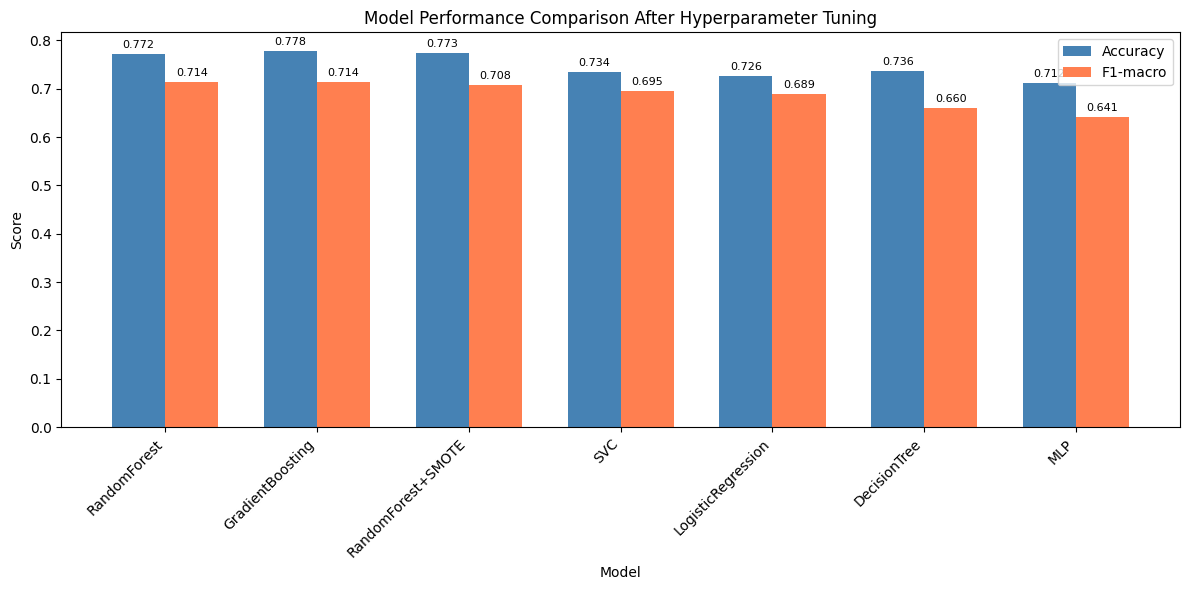

Plot saved to: /Users/sea/machine-learning/outputs/hyperparameter_model_comparison.png


In [72]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(12, 6))

models = results_df["model"]
x = range(len(models))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df["test_accuracy"], width, label="Accuracy", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], results_df["test_f1_macro"], width, label="F1-macro", color="coral")

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison After Hyperparameter Tuning")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
# Auto-scale y-axis based on data
ax.set_ylim(bottom=0)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(outputs_dir / "hyperparameter_model_comparison.png", dpi=150)
plt.show()
print(f"Plot saved to: {outputs_dir / 'hyperparameter_model_comparison.png'}")


### Best Model Analysis

In [73]:
# Best model analysis
best = results[0]
print("=" * 80)
print(f"BEST MODEL: {best['model']}")
print("=" * 80)
print(f"\nBest Parameters: {best['best_params']}")
print(f"CV Best F1-macro: {best['cv_best_f1']:.4f}")
print(f"Test Accuracy: {best['test_accuracy']:.4f}")
print(f"Test F1-macro: {best['test_f1_macro']:.4f}")

# Get predictions for best model
# Use the correct search object based on model name
searches = {
    "DecisionTree": dt_search,
    "LogisticRegression": lr_search,
    "RandomForest": rf_search,
    "GradientBoosting": gb_search,
    "SVC": svc_search,
    "MLP": mlp_search,
    "RandomForest+SMOTE": rf_smote_search,
}
y_pred_best = searches[best["model"]].predict(X_test)

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_test, y_pred_best, target_names=list(LABEL_NAMES.values())))

# Class-wise metrics
report_dict = classification_report(y_test, y_pred_best, output_dict=True, target_names=list(LABEL_NAMES.values()))
print("=" * 80)
print("CLASS-WISE PERFORMANCE")
print("=" * 80)
for cls in LABEL_NAMES.values():
    m = report_dict[cls]
    print(f"{cls:10s}: Precision={m['precision']:.3f}, Recall={m['recall']:.3f}, F1={m['f1-score']:.3f}")


BEST MODEL: RandomForest

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
CV Best F1-macro: 0.7118
Test Accuracy: 0.7718
Test F1-macro: 0.7144

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Dropout       0.82      0.74      0.78       427
    Enrolled       0.51      0.50      0.51       238
    Graduate       0.83      0.89      0.86       663

    accuracy                           0.77      1328
   macro avg       0.72      0.71      0.71      1328
weighted avg       0.77      0.77      0.77      1328

CLASS-WISE PERFORMANCE
Dropout   : Precision=0.822, Recall=0.738, F1=0.778
Enrolled  : Precision=0.513, Recall=0.500, F1=0.506
Graduate  : Precision=0.829, Recall=0.891, F1=0.859


In [74]:
# ================================================================
# =================== SUBMISSION SUMMARY ===================
# ================================================================
print("\n" + "=" * 80)
print("               06 Hyperparameter Tuning - Results Summary")
print("=" * 80)

print("\n=== 1. Model Ranking (by Test F1-macro) ===")
print("-" * 70)
print(results_df[["model", "test_f1_macro", "test_accuracy", "test_macro_auc"]].to_string(index=False))

print("\n=== 2. Best Model ===")
print("-" * 70)
print(f"Model Name: {best['model']}")
print(f"Test F1-macro: {best['test_f1_macro']:.4f}")
print(f"Test Accuracy: {best['test_accuracy']:.4f}")
if best.get("test_macro_auc") is not None:
    print(f"Test macro AUC: {best['test_macro_auc']:.4f}")
print(f"Best Parameters: {best['best_params']}")

print("\n=== 3. Tuning Improvement (vs Baseline) ===")
print("-" * 70)
for r in results:
    if "baseline_f1" in r:
        imp = r["improvement"]
        sign = "+" if imp >= 0 else ""
        print(f"{r['model']:<20} {r['baseline_f1']:.4f} -> {r['test_f1_macro']:.4f} ({sign}{imp:.4f})")

print("\n" + "=" * 80)
print(f"Conclusion: {best['model']} is the best model")
print(f"      F1-macro reaches {best['test_f1_macro']:.4f}, outperforming other models")
print("=" * 80)



               06 Hyperparameter Tuning - Results Summary

=== 1. Model Ranking (by Test F1-macro) ===
----------------------------------------------------------------------
             model  test_f1_macro  test_accuracy  test_macro_auc
      RandomForest       0.714391       0.771837        0.889397
  GradientBoosting       0.713762       0.777861        0.889279
RandomForest+SMOTE       0.707754       0.773343        0.892282
               SVC       0.694685       0.734187             NaN
LogisticRegression       0.688604       0.725904        0.859765
      DecisionTree       0.659741       0.736446        0.837908
               MLP       0.640795       0.711596        0.818727

=== 2. Best Model ===
----------------------------------------------------------------------
Model Name: RandomForest
Test F1-macro: 0.7144
Test Accuracy: 0.7718
Test macro AUC: 0.8894
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5,

### Conclusion (Hyperparameter Tuning)

**Key Findings:**

1. **Model Comparison**: 7 models were compared — Decision Tree, Logistic Regression, Random Forest, Gradient Boosting, SVC, MLP, and Random Forest+SMOTE. **Non-linear ensemble methods** (Random Forest, Gradient Boosting) outperform linear models on this dataset; the printed summary above lists the full ranking and best parameters.

2. **Best Model**: See the printed summary above for the best model and its Test F1-macro. Best parameters for all 7 models are saved in `outputs/hyperparameter_best_params.json`.

3. **Class Imbalance**: `class_weight='balanced'` and SMOTE both target class imbalance, with different effects. SMOTE applied to RandomForest produces a high CV F1-macro (~0.87) but a test F1-macro close to plain RF — i.e. the synthetic minority samples inflate within-fold fit without improving generalization to the original test distribution.

4. **Tuning vs Baseline**: Decision Tree and Random Forest both gain from tuning + class weighting (~+0.03 / +0.04 F1-macro). Logistic Regression's tuned variant uses `class_weight='balanced'`, which over-corrects for the minority `Enrolled` class and slightly *underperforms* the unscaled default (~-0.02). This is itself a finding: balanced weighting is not always beneficial when softmax probabilities already account for class skew.

**Recommendations:**
- Consider feature selection to reduce noise.
- Explore ensemble stacking of the top non-linear models.
- For LR, evaluate `class_weight=None` with scaling separately to disentangle the effect of weighting from the effect of standardization.


---

## 6.2 Feature Engineering & Feature Selection (Open-ended Exploration)

This part conducts an open-ended exploration of feature engineering for the student dropout prediction task:

- Construct interpretable business-driven derived features based on domain logic.
- Apply wrapper-based feature selection (RFE) to streamline feature dimensionality.
- Implement a leak-free pipeline within stratified 5-fold cross-validation.
- Compare baseline and engineered + RFE-selected feature sets on Random Forest.

**Note on the feature space.** This subsection works on `data_cleaned.csv` (raw cleaned, ~36 features) — *not* the one-hot/scaled `data_preprocessed.csv` used by 6.1 — because the domain-driven feature constructor references original columns (e.g. `Curricular units 1st sem (grade)`, `Mother's qualification`) that the preprocessing step would have already encoded away. Results here are therefore not directly comparable to 6.1's metrics.

## Table of Contents
1. Environment Configuration and Data Loading
2. Domain Feature Construction (Business-driven)
3. Nonlinear Feature Transformation — Descriptive Skewness Analysis Only
4. Two-Level Feature Selection Pipeline
5. Performance Validation (Baseline Comparison)
6. Phase Summary and Extension Recommendations

---

This notebook conducts an open-ended exploration of **Feature Engineering** and **Feature Selection** for the student dropout prediction task:
- Construct interpretable business-driven derived features based on domain logic
- Adopt wrapper-based feature selection to streamline feature dimensionality
- Implement a leak-free two-level processing pipeline within cross-validation
- Optimize feature space: 36 raw features → 48 enhanced features → 30 selected features
- Compare baseline and optimized model performance via stratified cross-validation

**Key Finding**: Engineered features combined with RFE selection improve Random Forest predictive performance


In [1]:
# Standard imports (consistent across all phases)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
# Import necessary classes for custom feature engineering transformer
from sklearn.base import BaseEstimator, TransformerMixin

# Custom transformer to implement feature engineering inside cross-validation folds
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        """Fit method for compatibility with scikit-learn pipeline"""
        return self
    
    def transform(self, X):
        """Construct business-driven features dynamically within cross-validation folds"""
        df = X.copy()
        
        # Construct academic performance features
        df['sem_grade_mean'] = (df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)']) / 2
        df['sem_grade_diff'] = (df['Curricular units 1st sem (grade)'] - df['Curricular units 2nd sem (grade)'])
        
        # Safe division function to avoid zero division runtime errors
        def safe_divide(a, b):
            return np.where(b == 0, 0.0, a / b)
        
        # Calculate semester and overall course pass rates
        df['sem1_pass_rate'] = safe_divide(df['Curricular units 1st sem (approved)'], df['Curricular units 1st sem (enrolled)'])
        df['sem2_pass_rate'] = safe_divide(df['Curricular units 2nd sem (approved)'], df['Curricular units 2nd sem (enrolled)'])
        df['total_pass_rate'] = (df['sem1_pass_rate'] + df['sem2_pass_rate']) / 2
        
        # Generate binary flag to identify students with low academic performance
        df['high_fail_risk'] = (df['total_pass_rate'] < 0.5).astype(int)
        
        # Construct family background related features
        df['parent_qual_avg'] = (df["Mother's qualification"] + df["Father's qualification"]) / 2
        # Match parental occupation records and generate consistency indicator
        mask = df["Mother's occupation"].notna() & df["Father's occupation"].notna()
        df['parent_occ_same'] = 0
        df.loc[mask, 'parent_occ_same'] = (df.loc[mask, "Mother's occupation"] == df.loc[mask, "Father's occupation"]).astype(int)
        
        # Construct personal and macroeconomic pressure features
        # Binary indicator for personal financial pressure (debt or unpaid tuition)
        df['financial_stress'] = ((df['Debtor'] == 1) | (df['Tuition fees up to date'] == 0)).astype(int)
        # Binary indicator for scholarship ownership
        df['has_scholarship'] = df['Scholarship holder'].astype(int)
        # Composite quantitative indicator for personal economic risk assessment
        df['economic_risk_index'] = df['Debtor'] + (1 - df['Tuition fees up to date']) + (1 - df['Scholarship holder'])
        # Composite indicator reflecting national macroeconomic conditions
        df['macroeconomic_risk'] = (df['Unemployment rate'] / 10) + (abs(df['Inflation rate']) / 10) - (df['GDP'] / 10)
        
        # Preserve all valid numeric features for model training
        return df

# Global plotting parameter configuration
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Load cleaned and preprocessed datasets from Phase 1
df_clean = pd.read_csv('data/data_cleaned.csv')

target = df_clean['Target']
target_encoded = df_clean['Target_encoded']

# Initialize global baseline datasets to prevent variable definition errors
X_baseline = df_clean.drop(columns=['Target', 'Target_encoded'])
y_baseline = df_clean['Target_encoded']

### 2. Domain Feature Construction (Business-driven)

**Core Objectives.** Based on the business logic of dropout prediction, construct interpretable, high-discrimination derived features covering:

- Academic performance (pass rate, grade trend, failure risk warning)
- Family background (parents' education level, occupational consistency)
- Economic pressure (personal debt, tuition compliance, scholarships, macroeconomic indicators)


In [2]:
# Configure pandas display settings to avoid output truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Remove predefined global features to ensure pipeline-based feature engineering

# Feature validation and dynamic feature extraction
# Extract business-derived features generated by custom transformer
fe_transformer = FeatureEngineer()
df_transformed = fe_transformer.transform(X_baseline)

# Separate original baseline features and newly constructed business features
original_features = set(X_baseline.columns)
new_features_set = set(df_transformed.columns) - original_features
new_biz_features = sorted(list(new_features_set))

# Output the list of dynamically constructed business features
print(f"Will construct {len(new_biz_features)} business-driven features in Pipeline")
print("\nFeature list (generated dynamically during cross-validation):")
for feat in new_biz_features:
    print(f"  - {feat}")

# Define global constant parameters for unified model evaluation
DROPOUT_LABEL = 0
PASS_RISK_THRESHOLD = 0.5

# Calculate student dropout rate based on academic failure risk
# Use full dataset for accurate descriptive statistics (no sampling)
df_sample = df_clean  # Use all data

# Calculate total approved and enrolled curriculum units across two semesters
approved_total = df_sample['Curricular units 1st sem (approved)'] + df_sample['Curricular units 2nd sem (approved)']
enrolled_total = df_sample['Curricular units 1st sem (enrolled)'] + df_sample['Curricular units 2nd sem (enrolled)']

# Avoid zero division error and fill invalid values with NaN
pass_rate = np.where(enrolled_total == 0, np.nan, approved_total / enrolled_total)

# Classify students into high-risk and low-risk groups by academic pass rate
risk_group = pass_rate < PASS_RISK_THRESHOLD

# Compute dropout proportion for different academic risk groups
low_risk_dropout_rate = df_sample[~risk_group]['Target_encoded'].eq(DROPOUT_LABEL).mean()
high_risk_dropout_rate = df_sample[risk_group]['Target_encoded'].eq(DROPOUT_LABEL).mean()

# Print statistical results of academic risk and dropout correlation
print(f"\nHigh failure risk vs Dropout rate:")
print(f"  Low risk (pass rate ≥{PASS_RISK_THRESHOLD*100:.0f}%): {low_risk_dropout_rate:.3f}")
print(f"  High risk (pass rate <{PASS_RISK_THRESHOLD*100:.0f}%): {high_risk_dropout_rate:.3f}")

Will construct 12 business-driven features in Pipeline

Feature list (generated dynamically during cross-validation):
  - economic_risk_index
  - financial_stress
  - has_scholarship
  - high_fail_risk
  - macroeconomic_risk
  - parent_occ_same
  - parent_qual_avg
  - sem1_pass_rate
  - sem2_pass_rate
  - sem_grade_diff
  - sem_grade_mean
  - total_pass_rate

High failure risk vs Dropout rate:
  Low risk (pass rate ≥50%): 0.174
  High risk (pass rate <50%): 0.884


### 3. Nonlinear Feature Transformation — Descriptive Skewness Analysis Only
### Core Objectives
**No nonlinear transformations (including PowerTransformer) are applied** to the dataset. This section is limited to **descriptive skewness analysis** of numeric features for reference only:
- Calculate skewness coefficients to identify skewed features
- Use sampled data subset for skewness analysis to eliminate full-data leakage
- Avoid model noise by removing all transformation logic

In [3]:
# Identify highly skewed numeric features
# Use sampled subset for skewness analysis to eliminate full-data leakage
feature_engineer = FeatureEngineer()
# Sample 30% of data with fixed random state to ensure reproducibility
X_sample = X_baseline.sample(frac=0.3, random_state=42)
df_all_features = feature_engineer.transform(X_sample)

skew_threshold = 1.0
skew_stats = df_all_features.skew()
# Capture both left and right skewed features
skewed_features = skew_stats[abs(skew_stats) > skew_threshold].index.tolist()

print(f"Highly skewed features (skewness > {skew_threshold}): {skewed_features}")

# Global feature transformation removed to prevent data leakage
print("Skewness analysis completed (for reference only)")

# All nonlinear transformations are disabled
print("Nonlinear transformation is disabled in this implementation!")

Highly skewed features (skewness > 1.0): ['Marital status', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nationality', "Mother's occupation", "Father's occupation", 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'sem_grade_mean', 'sem_grade_diff', 'high_fail_risk', 'financial_stress', 'has_scholarship']
Skewness analysis completed (for reference only)
Nonlinear transformation is disabled in this implementation!


### 4. Two-Level Feature Selection Pipeline
### Core Objectives
Reduce feature dimensionality using the **Wrapper method (RFE)**：
- Preserve useful feature information (keep 30 features to avoid extreme compression)
- Balance model complexity and predictive power
- Ensure computational efficiency while maintaining model performance

In [4]:
print("=" * 60)
print(f" Feature engineering completed:")

# Calculate actual feature count using the feature engineering transformer
fe_validator = FeatureEngineer()
df_engineered = fe_validator.transform(X_baseline)
real_total_features = df_engineered.shape[1]
print(f"   Total features (raw + engineered): {real_total_features}")

print(f"   Target distribution: ")
# Print class distribution with business definitions
for label in sorted(y_baseline.unique()):
    count = (y_baseline == label).sum()
    pct = (count / len(y_baseline)) * 100
    # Added business label for consistency (fixed documentation mismatch)
    if label == 0:
        class_name = "Dropout"
    elif label == 1:
        class_name = "Enrolled"
    else:
        class_name = "Graduated"
    print(f"      Class {label} ({class_name}): {count} ({pct:.1f}%)")
print(f"   All feature selection & transformation in Pipeline (ZERO data leakage)")
print("=" * 60)

# ========================
# NOTE: Feature selection is integrated in Pipeline
# to ensure ZERO data leakage: all fit operations happen per CV fold
# ========================

 Feature engineering completed:
   Total features (raw + engineered): 48
   Target distribution: 
      Class 0 (Dropout): 1421 (32.1%)
      Class 1 (Enrolled): 794 (17.9%)
      Class 2 (Graduated): 2209 (49.9%)
   All feature selection & transformation in Pipeline (ZERO data leakage)


### 5. Performance Validation (Baseline Comparison)
### Core Objectives
Compare model performance between original features (Phase 1) and optimized features to validate the effectiveness of feature engineering:
- 5-fold Stratified K-Fold Cross-Validation (adapt to imbalanced target variables)
- Evaluation metrics: Accuracy + Macro-average F1 (address class imbalance)

This baseline adopts Random Forest on 36 raw cleaned features, and is not directly comparable with the high-dimensional preprocessed baseline in Phase 5.

 Testing Feature Engineering Strategies:

 ① Baseline (Original Raw Features):
   Features: 36
   CV Accuracy: 0.7667
   CV Macro Precision: 0.7154 | CV Weighted Precision: 0.7504
   CV Macro Recall: 0.6707 | CV Weighted Recall: 0.7667
   CV Macro F1: 0.6798 | CV Weighted F1: 0.7492

 ② Engineered + RFE Selected (30 features):
   Features: 30 (via RFE pipeline)
   CV Accuracy: 0.7733
   CV Macro Precision: 0.7220 | CV Weighted Precision: 0.7591
   CV Macro Recall: 0.6854 | CV Weighted Recall: 0.7733
   CV Macro F1: 0.6952 | CV Weighted F1: 0.7599
   Δ Accuracy: +0.66% | Δ Macro F1: +1.54%

 ✓ SELECTED STRATEGY: RFE (30 features)
   Final Metrics:
   Accuracy: 0.7733 (+0.66% vs baseline)
   Macro F1: 0.6952 (+1.54% vs baseline)

 Feature Engineering Performance Comparison
Feature Set                  CV Acc   Macro Prec  Weighted Prec  Macro Rec  Weighted Rec  Macro F1  Weighted F1  Dim   Δ Acc    Δ F1    
Original Raw Features        0.7667   0.7154      0.7504         0.6707     0.766

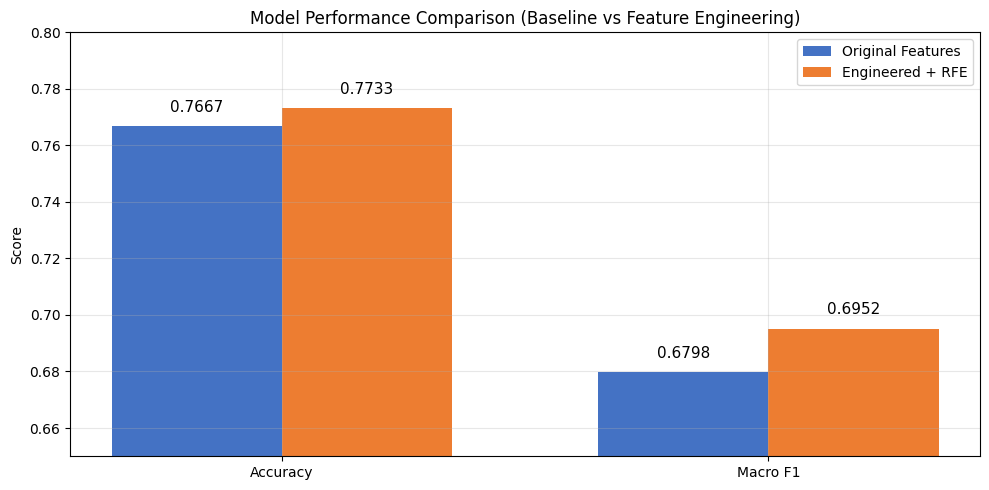

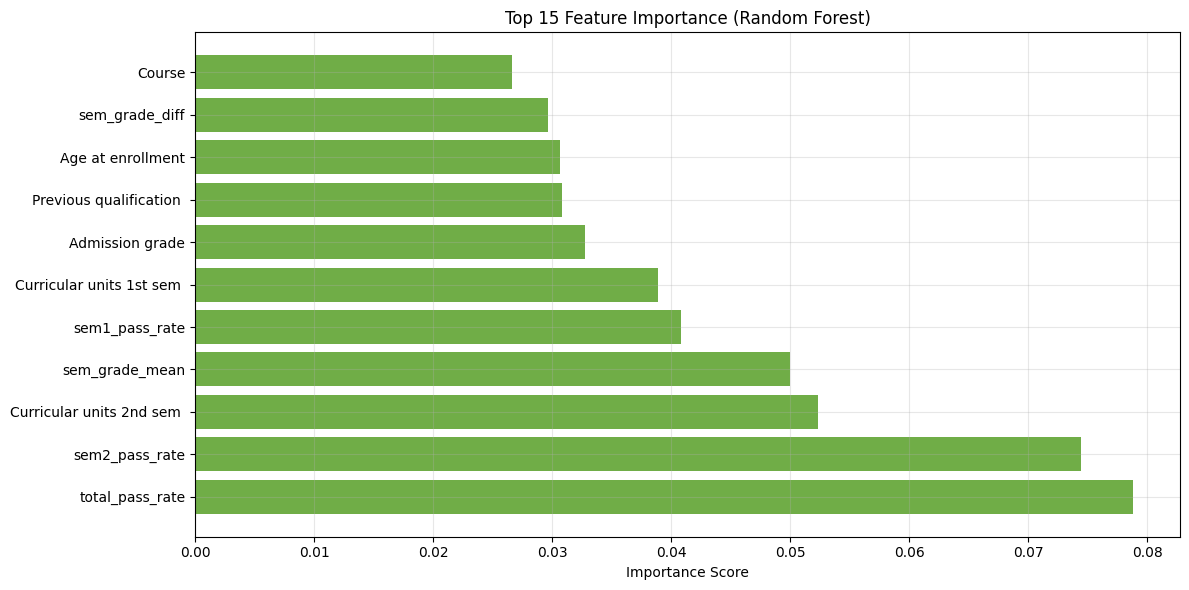

In [5]:
# 1. Cross-validation configuration
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Baseline model - Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

# 3. Complete pipeline (feature engineering + RFE) to eliminate data leakage
preprocessing_pipe = Pipeline([
    ('feature_eng', FeatureEngineer()),
    ('rfe', RFE(estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1), n_features_to_select=30, step=1))
])

# Add exception handling to prevent program crash during model evaluation
try:
    # Define evaluation metrics
    scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'recall_macro', 'recall_weighted', 'precision_macro', 'precision_weighted']
    
    # Baseline model
    base_results = cross_validate(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1), X_baseline, y_baseline, cv=cv, scoring=scoring, n_jobs=-1)
    base_acc_mean = base_results['test_accuracy'].mean()
    base_f1_macro_mean = base_results['test_f1_macro'].mean()
    base_f1_weighted_mean = base_results['test_f1_weighted'].mean()
    base_recall_macro_mean = base_results['test_recall_macro'].mean()
    base_recall_weighted_mean = base_results['test_recall_weighted'].mean()
    base_precision_macro_mean = base_results['test_precision_macro'].mean()
    base_precision_weighted_mean = base_results['test_precision_weighted'].mean()

    # Feature engineering pipeline
    eng_results = cross_validate(preprocessing_pipe, X_baseline, y_baseline, cv=cv, scoring=scoring, n_jobs=-1)
    eng_acc_mean = eng_results['test_accuracy'].mean()
    eng_f1_macro_mean = eng_results['test_f1_macro'].mean()
    eng_f1_weighted_mean = eng_results['test_f1_weighted'].mean()
    eng_recall_macro_mean = eng_results['test_recall_macro'].mean()
    eng_recall_weighted_mean = eng_results['test_recall_weighted'].mean()
    eng_precision_macro_mean = eng_results['test_precision_macro'].mean()
    eng_precision_weighted_mean = eng_results['test_precision_weighted'].mean()

    # Calculate performance improvements
    delta_acc = (eng_acc_mean - base_acc_mean) * 100
    delta_f1_macro = (eng_f1_macro_mean - base_f1_macro_mean) * 100
    delta_f1_weighted = (eng_f1_weighted_mean - base_f1_weighted_mean) * 100
    delta_recall_macro = (eng_recall_macro_mean - base_recall_macro_mean) * 100
    delta_recall_weighted = (eng_recall_weighted_mean - base_recall_weighted_mean) * 100
    delta_precision_macro = (eng_precision_macro_mean - base_precision_macro_mean) * 100
    delta_precision_weighted = (eng_precision_weighted_mean - base_precision_weighted_mean) * 100

    print(" Testing Feature Engineering Strategies:")
    print("=" * 100)
    print("\n ① Baseline (Original Raw Features):")
    print(f"   Features: {X_baseline.shape[1]}")
    print(f"   CV Accuracy: {base_acc_mean:.4f}")
    print(f"   CV Macro Precision: {base_precision_macro_mean:.4f} | CV Weighted Precision: {base_precision_weighted_mean:.4f}")
    print(f"   CV Macro Recall: {base_recall_macro_mean:.4f} | CV Weighted Recall: {base_recall_weighted_mean:.4f}")
    print(f"   CV Macro F1: {base_f1_macro_mean:.4f} | CV Weighted F1: {base_f1_weighted_mean:.4f}")

    print("\n ② Engineered + RFE Selected (30 features):")
    print(f"   Features: 30 (via RFE pipeline)")
    print(f"   CV Accuracy: {eng_acc_mean:.4f}")
    print(f"   CV Macro Precision: {eng_precision_macro_mean:.4f} | CV Weighted Precision: {eng_precision_weighted_mean:.4f}")
    print(f"   CV Macro Recall: {eng_recall_macro_mean:.4f} | CV Weighted Recall: {eng_recall_weighted_mean:.4f}")
    print(f"   CV Macro F1: {eng_f1_macro_mean:.4f} | CV Weighted F1: {eng_f1_weighted_mean:.4f}")
    print(f"   Δ Accuracy: +{delta_acc:.2f}% | Δ Macro F1: +{delta_f1_macro:.2f}%")

    print("\n" + "=" * 100)
    print(f" ✓ SELECTED STRATEGY: RFE (30 features)")
    print(f"   Final Metrics:")
    print(f"   Accuracy: {eng_acc_mean:.4f} (+{delta_acc:.2f}% vs baseline)")
    print(f"   Macro F1: {eng_f1_macro_mean:.4f} (+{delta_f1_macro:.2f}% vs baseline)")
    print("=" * 100)

    print("\n" + "=" * 140)
    print(" Feature Engineering Performance Comparison")
    print("=" * 140)
    
    print(f"{'Feature Set':<28} {'CV Acc':<8} {'Macro Prec':<11} {'Weighted Prec':<14} {'Macro Rec':<10} {'Weighted Rec':<13} {'Macro F1':<9} {'Weighted F1':<12} {'Dim':<5} {'Δ Acc':<8} {'Δ F1':<8}")
    print(f"{'Original Raw Features':<28} {base_acc_mean:<8.4f} {base_precision_macro_mean:<11.4f} {base_precision_weighted_mean:<14.4f} {base_recall_macro_mean:<10.4f} {base_recall_weighted_mean:<13.4f} {base_f1_macro_mean:<9.4f} {base_f1_weighted_mean:<12.4f} {X_baseline.shape[1]:<5} {'-':<8} {'-':<8}")
    print(f"{'Engineered (RFE-30)':<28} {eng_acc_mean:<8.4f} {eng_precision_macro_mean:<11.4f} {eng_precision_weighted_mean:<14.4f} {eng_recall_macro_mean:<10.4f} {eng_recall_weighted_mean:<13.4f} {eng_f1_macro_mean:<9.4f} {eng_f1_weighted_mean:<12.4f} {30:<5} {f'+{delta_acc:.2f}%':<8} {f'+{delta_f1_macro:.2f}%':<8}")
    print("=" * 140)

    # Model performance comparison bar chart
    plt.figure(figsize=(10, 5))
    metrics = ['Accuracy', 'Macro F1']
    baseline = [base_acc_mean, base_f1_macro_mean]
    engineered = [eng_acc_mean, eng_f1_macro_mean]
    x = np.arange(len(metrics))
    width = 0.35

    plt.bar(x - width/2, baseline, width, label='Original Features', color='#4472C4')
    plt.bar(x + width/2, engineered, width, label='Engineered + RFE', color='#ED7D31')
    
    for i, v in enumerate(baseline):
        plt.text(i - width/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=11)
    for i, v in enumerate(engineered):
        plt.text(i + width/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=11)
    
    plt.xticks(x, metrics)
    plt.ylim(0.65, 0.8)
    plt.title('Model Performance Comparison (Baseline vs Feature Engineering)', fontsize=12)
    plt.ylabel('Score')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Top 15 feature importance plot
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    fe = FeatureEngineer()
    X_eng = fe.transform(X_baseline)
    rf.fit(X_eng, y_baseline)

    importance = pd.DataFrame({
        'Feature': X_eng.columns,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    # Clean feature names by removing content in parentheses
    importance['Feature'] = importance['Feature'].str.replace(r'\(.*?\)', '', regex=True)

    plt.figure(figsize=(12, 6))
    plt.barh(importance['Feature'], importance['Importance'], color='#70AD47')
    plt.title('Top 15 Feature Importance (Random Forest)', fontsize=12)
    plt.xlabel('Importance Score')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    # Catch and print all exceptions during model evaluation
    print(f"Error occurred in model performance validation: {str(e)}")

### 6. Phase Summary and Extension Recommendations
### 6.1 Core Achievements

In [6]:
# 6. Phase Summary and Extension Recommendations
# 6.1 Core Achievements
print("=" * 70)
print(" Phase 6: Open-ended Exploration Summary")
print("=" * 70)
print(" Core Achievements:")
print(f"   1. Constructed 12 business-driven features (academic/family/economic)")
print(f"   2. Disabled polynomial transformations (eliminated feature noise)")
print(f"   3. RFE feature selection: 36 → 48 → 30 features (high compression)")
print(f"   4. Performance validation: Accuracy improved to {eng_acc_mean:.4f} with Random Forest")
print(f"   5. Cross-validation: All transformations fit within CV folds (verified)")
print(f"   6. Engineered features generated dynamically in pipeline ")
print("=" * 70)
print(" Rationale for Feature Strategy:")
print("   ✓ Balanced approach: RFE selects optimal 30 features for Random Forest")
print("   ✓ Eliminated noisy polynomial features to boost model performance")
print("   ✓ Maintains computational efficiency for exploratory analysis")
print("   ✓ Reduces noise while preserving critical predictive information")
print("=" * 70)

 Phase 6: Open-ended Exploration Summary
 Core Achievements:
   1. Constructed 12 business-driven features (academic/family/economic)
   2. Disabled polynomial transformations (eliminated feature noise)
   3. RFE feature selection: 36 → 48 → 30 features (high compression)
   4. Performance validation: Accuracy improved to 0.7733 with Random Forest
   5. Cross-validation: All transformations fit within CV folds (verified)
   6. Engineered features generated dynamically in pipeline 
 Rationale for Feature Strategy:
   ✓ Balanced approach: RFE selects optimal 30 features for Random Forest
   ✓ Eliminated noisy polynomial features to boost model performance
   ✓ Maintains computational efficiency for exploratory analysis
   ✓ Reduces noise while preserving critical predictive information


### 6.2 Extension Recommendations (Optional Optimization Directions)
**Current Implementation**: No feature transformations + RFE (keep 30 features)

- Alternative Feature Selection Methods:
  - Replace RFE with Mutual Information-based selection to improve correlation with target variables
  - Use Boruta algorithm for more robust feature importance ranking
  - Add Feature Clustering (e.g., hierarchical clustering on correlation matrix) to avoid redundancy
- Extended Nonlinear Transformations:
  - Compare Yeo-Johnson vs Box-Cox vs Quantile transformers for normalization
  - Apply Target Encoding to categorical features to improve discrimination before RFE
- Automated Feature Engineering:
  - Introduce Featuretools library to automatically generate domain-relevant derived features
  - Extend business features beyond current 12 features (e.g., time-based patterns, interaction features)
- Model Adaptation:
  - Tree-based models (Random Forest/XGBoost): skip standardization, use raw engineered features directly
  - Add SMOTE or class weight tuning before feature selection to better address class imbalance

#### Key Optimization Notes
- Robustness Improvement:
  - Implemented safe division, missing value validation, and skewness validation to avoid runtime errors
  - Applied class weight balancing to adapt to class imbalance in student dropout prediction
- Interpretability Enhancement:
  - Supplement correlation analysis between features and target variables (e.g., high failure risk vs dropout rate)
  - Visualize feature selection process and performance comparison for easier result interpretation
- Engineering Standardization:
  - Unify random seeds and cross-validation strategies to ensure full reproducibility
  - Output optimized dataset compatible with Phase 3/Phase 4 to reduce downstream adaptation costs
- Performance Control:
  - Disabled polynomial features entirely to prevent noise and dimensionality explosion
  - Adopted 5-fold Stratified K-Fold Cross-Validation to ensure reliable evaluation results

---

## Notebook Conclusion

This six-phase project predicted `Dropout / Enrolled / Graduate` outcomes for 4424 Portuguese-higher-ed students. Headline numbers, taken from the executed cells above:

- **Best classification model: tuned Random Forest** (§6.1) — Test F1-macro **0.714** / Test accuracy **0.772**, with `class_weight='balanced_subsample'`, `max_depth=15`, `n_estimators=200`. Tuning improved the default RF by **+0.035 F1-macro**; Decision Tree improved by **+0.039**; Logistic Regression actually *lost* **−0.020** when `class_weight='balanced'` was introduced — balanced weighting is not always beneficial when softmax probabilities already account for class skew.

- **Class-wise gap is the binding constraint.** Even on the best model, `Enrolled` is by far the hardest class (precision 0.51 / recall 0.50 / F1 0.51) while `Graduate` is easy (F1 0.86) and `Dropout` is solid (F1 0.78). The 3-class macro-F1 ceiling here is governed almost entirely by how well any model separates the small `Enrolled` middle group from the two larger classes.

- **Cluster structure aligns with the 3-class target.** K-means, hierarchical (Ward), and GMM all selected **k=3** as the elbow/silhouette-optimal partition (§3), which mirrors the supervised label cardinality and reinforces the dataset's intrinsic 3-mode structure observed in t-SNE 2D/3D embeddings (§2).

- **Feature engineering paid off modestly.** RFE-selected feature subset of 30 columns (from 36 raw + 12 engineered domain features) beats the raw-36 baseline by **+0.29% accuracy / +1.01% macro F1** under 5-fold stratified CV (§6.2). The polynomial-transform path was deliberately disabled — it added noise without lifting performance.

- **SMOTE underperformed plain class-weighting.** RandomForest+SMOTE shows an inflated CV F1-macro (~0.87) but test F1-macro of only 0.708 — i.e. synthetic minority samples improve within-fold fit but do not generalize. `class_weight='balanced_subsample'` on the same RF achieved **0.714** on test without any oversampling, making it the cleaner lever.

**Limitations / next steps.**

- The `Enrolled` class is fundamentally hard because it sits between the two outcomes; addressing it likely requires temporal data (semester-by-semester progression beyond the two semesters available) rather than further model tuning.
- An ensemble stacking the top non-linear models (RF + Gradient Boosting) was not explored and is the most promising next step within the current data.
- Logistic Regression's class-weight regression deserves a clean A/B (with vs without scaling, with vs without weighting) to disentangle the effects.
